# City Brain — Proposal-Aligned EDA
**COMP 9130 Final Project — Group 5**

This notebook performs exploratory data analysis on the **4 core datasets** required by our proposal:
1. **Pavement Condition Rating** (~8,000 segments) — PCI scores + distress sub-scores
2. **311 Service Requests** (~180,000 records, 2019–2025) — citizen complaint data
3. **Weather Data** (Environment Canada, 2019–2025) — temperature, precipitation, freeze-thaw
4. **Infrastructure Condition Report** (~8,000 segments) — segment age, material, repair history

**Goals:**
- Validate data quality, missing values, and class distribution for each dataset
- Derive the risk label (PCI >= 70 → Low, 40–69 → Medium, < 40 → High) and check class imbalance
- Construct time-series features (complaint frequency, weather rolling windows)
- Verify segment ID join consistency across all 4 datasets
- Engineer key features: freeze-thaw cycles, cumulative precipitation, complaint frequency

---
## Part 0 — Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Environment ready.')

Environment ready.


### 0.1 Download datasets from Vancouver Open Data & Environment Canada

We pull the 4 core datasets directly from public APIs. If files already exist locally, we skip the download.

In [2]:
import os, urllib.request

DATA_DIR = '../data/'
os.makedirs(DATA_DIR, exist_ok=True)

DATASETS = {
    'pavement_condition.csv':
        'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/pavement-condition-rating/exports/csv?limit=-1&timezone=America%2FVancouver&use_labels=true&epsg=4326',
    '311_service_requests.csv':
        'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/3-1-1-service-requests/exports/csv?limit=-1&timezone=America%2FVancouver&use_labels=true&epsg=4326',
}

WEATHER_YEARS = range(2019, 2026)
WEATHER_STATION_ID = 51442

for fname, url in DATASETS.items():
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, fpath)
        print(f'  Saved to {fpath}')
    else:
        print(f'{fname} already exists, skipping.')

weather_path = os.path.join(DATA_DIR, 'weather_vancouver.csv')
if not os.path.exists(weather_path):
    weather_frames = []
    for year in WEATHER_YEARS:
        url = (f'https://climate.weather.gc.ca/climate_data/bulk_data_e.html'
               f'?format=csv&stationID={WEATHER_STATION_ID}&Year={year}'
               f'&Month=1&Day=1&timeframe=2')
        print(f'Downloading weather {year}...')
        try:
            df_w = pd.read_csv(url)
            weather_frames.append(df_w)
        except Exception as e:
            print(f'  Warning: {e}')
    if weather_frames:
        pd.concat(weather_frames, ignore_index=True).to_csv(weather_path, index=False)
else:
    print('weather_vancouver.csv already exists, skipping.')

# Infrastructure datasets already in data/ folder
for f in ['public_streets.csv', 'right_of_way_widths.csv', 'directional_traffic_count_locations.csv', 'city_project_package_street.csv']:
    print(f'{f}: {"found" if os.path.exists(os.path.join(DATA_DIR, f)) else "MISSING"}')

print('\nAll downloads complete.')


  Saved to ../data/pavement_condition.csv
  Saved to ../data/311_service_requests.csv
public_streets.csv: MISSING
right_of_way_widths.csv: MISSING
directional_traffic_count_locations.csv: MISSING
city_project_package_street.csv: MISSING

All downloads complete.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load all data sources
df_pavement = pd.read_csv(os.path.join(DATA_DIR, 'pavement_condition.csv'), sep=';', on_bad_lines='skip')
df_311 = pd.read_csv(os.path.join(DATA_DIR, '311_service_requests.csv'), sep=';', on_bad_lines='skip')
df_weather = pd.read_csv(os.path.join(DATA_DIR, 'weather_vancouver.csv'))

# Infrastructure = 4 local datasets
df_streets = pd.read_csv(os.path.join(DATA_DIR, 'public_streets.csv'))
df_row = pd.read_csv(os.path.join(DATA_DIR, 'right_of_way_widths.csv'))
df_traffic = pd.read_csv(os.path.join(DATA_DIR, 'directional_traffic_count_locations.csv'))
df_repairs = pd.read_csv(os.path.join(DATA_DIR, 'city_project_package_street.csv'))

print(f'Pavement Condition:  {df_pavement.shape}')
print(f'311 Requests:        {df_311.shape}')
print(f'Weather:             {df_weather.shape}')
print(f'--- Infrastructure ---')
print(f'Public Streets:      {df_streets.shape}')
print(f'ROW Widths:          {df_row.shape}')
print(f'Traffic Counts:      {df_traffic.shape}')
print(f'Repair Projects:     {df_repairs.shape}')


Pavement Condition:  (9016, 8)
311 Requests:        (1155936, 13)
Weather:             (2557, 31)
--- Infrastructure ---
Public Streets:      (1710, 4)
ROW Widths:          (2690, 3)
Traffic Counts:      (670, 3)
Repair Projects:     (40, 6)


In [8]:
def dataset_overview(df, name):
    """Print shape, dtypes, and missing value summary for a dataframe."""
    print('=' * 70)
    print(f'Dataset: {name}')
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'\nColumn Info:')
    for col in df.columns:
        missing = df[col].isna().sum()
        pct = missing / len(df) * 100
        dtype = df[col].dtype
        print(f'  {col:40s} {str(dtype):12s} missing: {missing:6d} ({pct:.1f}%)')
    print()

dataset_overview(df_pavement, 'Pavement Condition Rating')
dataset_overview(df_311, '311 Service Requests')
dataset_overview(df_weather, 'Weather (Environment Canada)')
dataset_overview(df_infra, 'Infrastructure Condition Report')

Dataset: Pavement Condition Rating
Shape: 9,016 rows x 8 columns

Column Info:
  Year                                     int64        missing:      0 (0.0%)
  Road Name                                object       missing:      0 (0.0%)
  From Street                              object       missing:      0 (0.0%)
  To Street                                object       missing:      0 (0.0%)
  length_(m)                               int64        missing:      0 (0.0%)
  PCI Rating                               object       missing:      0 (0.0%)
  Geom                                     object       missing:      0 (0.0%)
  geo_point_2d                             object       missing:      0 (0.0%)

Dataset: 311 Service Requests
Shape: 1,155,936 rows x 13 columns

Column Info:
  Department                               object       missing:      0 (0.0%)
  Service request type                     object       missing:      0 (0.0%)
  Status                                   object  

NameError: name 'df_infra' is not defined

---
## Part 1 — Dataset Overview & Quality Check

For each dataset: shape, dtypes, missing values percentage, and sample rows.

In [9]:
dataset_overview(df_pavement, 'Pavement Condition Rating')
dataset_overview(df_311, '311 Service Requests')
dataset_overview(df_weather, 'Weather (Environment Canada)')
dataset_overview(df_streets, 'Public Streets')
dataset_overview(df_row, 'Right-of-Way Widths')
dataset_overview(df_traffic, 'Traffic Count Locations')
dataset_overview(df_repairs, 'Repair Projects')


Dataset: Pavement Condition Rating
Shape: 9,016 rows x 8 columns

Column Info:
  Year                                     int64        missing:      0 (0.0%)
  Road Name                                object       missing:      0 (0.0%)
  From Street                              object       missing:      0 (0.0%)
  To Street                                object       missing:      0 (0.0%)
  length_(m)                               int64        missing:      0 (0.0%)
  PCI Rating                               object       missing:      0 (0.0%)
  Geom                                     object       missing:      0 (0.0%)
  geo_point_2d                             object       missing:      0 (0.0%)

Dataset: 311 Service Requests
Shape: 1,155,936 rows x 13 columns

Column Info:
  Department                               object       missing:      0 (0.0%)
  Service request type                     object       missing:      0 (0.0%)
  Status                                   object  

In [10]:
print('=== Pavement Condition ===')
display(df_pavement.head(3))
print('\n=== 311 Service Requests ===')
display(df_311.head(3))
print('\n=== Weather ===')
display(df_weather.head(3))
print('\n=== Public Streets ===')
display(df_streets.head(3))
print('\n=== ROW Widths ===')
display(df_row.head(3))
print('\n=== Repair Projects ===')
display(df_repairs.head(3))


=== Pavement Condition ===


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,54TH AV,LAUREL ST,HEATHER ST,114,GOOD,"{""coordinates"": [[-123.12532004923742, 49.2214...","49.22148553629358, -123.12453745940311"
1,2020,50TH AV,CARTIER ST,HUDSON ST,172,VERY GOOD,"{""coordinates"": [[-123.13748571496699, 49.2258...","49.22579760512825, -123.13630485869659"
2,2020,6TH AV,NOOTKA ST,LILLOOET ST,184,POOR,"{""coordinates"": [[-123.0415487999513, 49.26475...","49.26474861127686, -123.04028428411264"



=== 311 Service Requests ===


,Department,Service request type,Status,Closure reason,Service request open timestamp,Service request close date,Last modified timestamp,Address,Local area,Channel,Latitude,Longitude,geom
0,DBL - Licence Office,Business Licence Request Case,Close,Service provided,2022-11-28T10:10:00-08:00,2022-12-01,2022-12-01T13:13:53-08:00,NaN,NaN,WEB,NaN,NaN,NaN
1,FSC - Vacancy Tax,Empty Homes Tax Request Case,Close,Service provided,2022-11-28T10:16:07-08:00,2022-11-28,2022-11-28T13:59:35-08:00,NaN,Victoria-Fraserview,Phone,NaN,NaN,NaN
2,ENG - Sanitation Services,Missed Green Bin Pickup Case,Close,Service provided,2022-11-28T10:17:00-08:00,2022-11-29,2022-11-29T15:03:27-08:00,NaN,Kensington-Cedar Cottage,Phone,NaN,NaN,NaN



=== Weather ===


...

,geom,hblock,streetuse,geo_point_2d
0,"{'type': 'Feature', 'geometry': {'coordinates'...",2700 E 22ND AV,Collector,"{'lon': -123.04800238800782, 'lat': 49.2506491..."
1,"{'type': 'Feature', 'geometry': {'coordinates'...",700 W HASTINGS ST,Arterial,"{'lon': -123.11436174987927, 'lat': 49.2856285..."
2,"{'type': 'Feature', 'geometry': {'coordinates'...",1200 ROBSON ST,Arterial,"{'lon': -123.12744448000852, 'lat': 49.2863056..."



=== ROW Widths ===


,geom,width,geo_point_2d
0,"{'type': 'Feature', 'geometry': {'coordinates'...",66.0,"{'lon': -123.02193613306062, 'lat': 49.2563751..."
1,"{'type': 'Feature', 'geometry': {'coordinates'...",66.0,"{'lon': -123.01371706055507, 'lat': 49.2581032..."
2,"{'type': 'Feature', 'geometry': {'coordinates'...",66.0,"{'lon': -123.01746032750835, 'lat': 49.2495892..."



=== Repair Projects ===


,expected_completion_date,location,project_title,url_link,geom,geo_point_2d
0,2024-08-28,Oak Street and W 70th Av intersection,Oak Street Upgrades - Phase 3 (Oak Street and ...,http://vanmapp1.vancouver.ca/roadahead/events/...,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.13023872145713, 'lat': 49.2087284..."
1,2026-03-24,Both Sides of Lane South of 900 Block of E 11t...,FortisBC Gas Service Connection on Lane South ...,http://vanmapp1.vancouver.ca/roadahead/events/...,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.08463388910836, 'lat': 49.2601402..."
2,2026-03-25,Both Sides of 1000 Block of Maxine Lane From T...,Telus Utility Maintenance on 1000 Block of Max...,http://vanmapp1.vancouver.ca/roadahead/events/...,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.13268873536283, 'lat': 49.2792599..."


### 1.1 Missing Value Heatmap

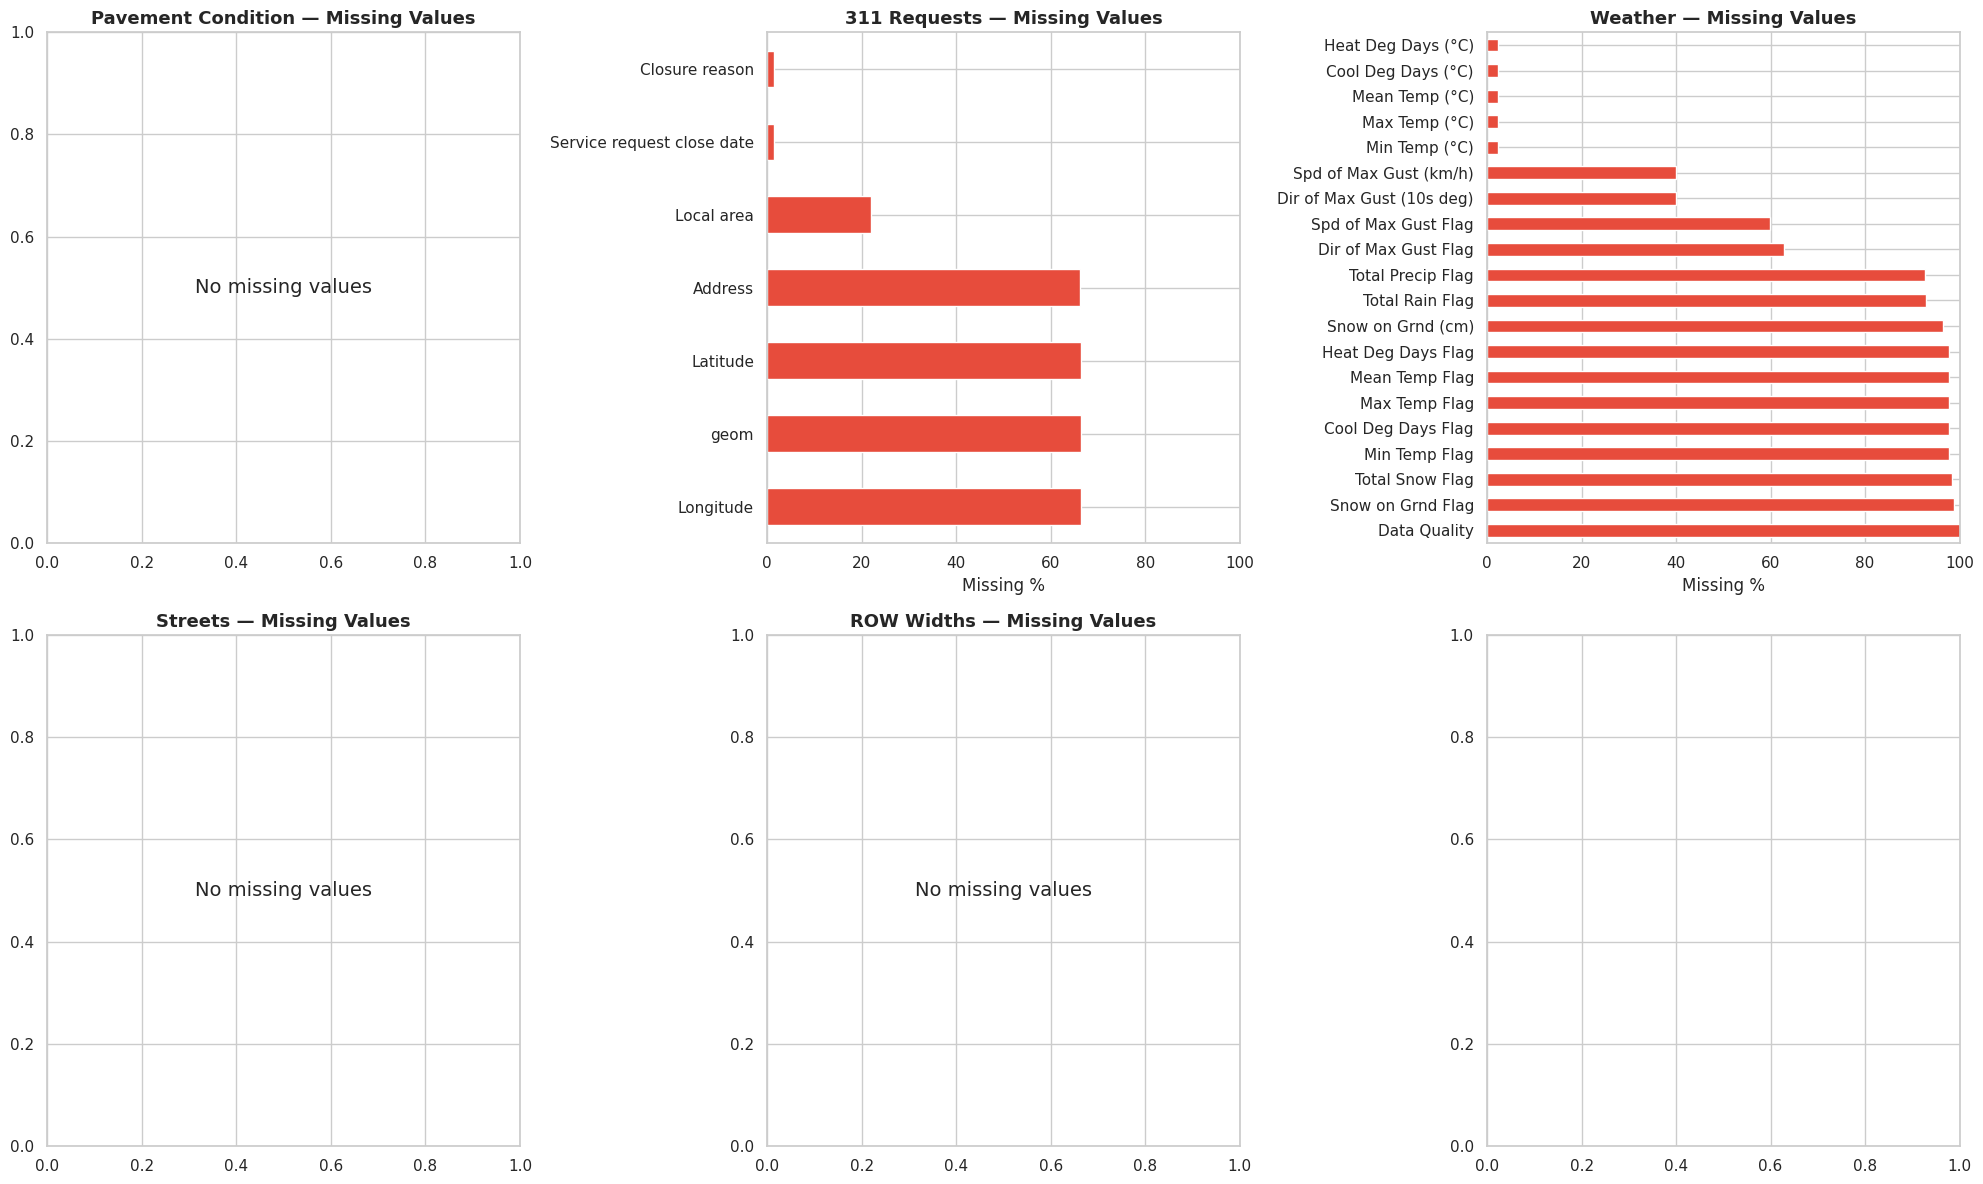

Saved: missing_values.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

datasets_dict = {
    'Pavement Condition': df_pavement,
    '311 Requests': df_311,
    'Weather': df_weather,
    'Streets': df_streets, 'ROW Widths': df_row
}

for ax, (name, df) in zip(axes.flat, datasets_dict.items()):
    # Show missing % per column
    missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    # Only show columns with > 0% missing, up to 20
    missing_pct = missing_pct[missing_pct > 0].head(20)
    if len(missing_pct) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
        ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
        continue
    missing_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 100)

plt.tight_layout()
# plt.savefig('../EDA/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: missing_values.png')

---
## Part 2 — Pavement Condition Analysis & Risk Label Derivation

The proposal defines risk labels as:
- **Low risk**: PCI >= 70
- **Medium risk**: PCI 40–69
- **High risk**: PCI < 40

This section examines PCI distribution and checks for class imbalance (a known concern from the briefing).

In [12]:
# Identify the PCI rating column
print(f'All pavement columns: {list(df_pavement.columns)}')
print(f'\nDtypes:')
print(df_pavement.dtypes)
print(f'\nSample rows:')
display(df_pavement.head(5))


All pavement columns: ['Year', 'Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'Geom', 'geo_point_2d']

Dtypes:
Year             int64
Road Name       object
From Street     object
To Street       object
length_(m)       int64
PCI Rating      object
Geom            object
geo_point_2d    object
dtype: object

Sample rows:


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,54TH AV,LAUREL ST,HEATHER ST,114,GOOD,"{""coordinates"": [[-123.12532004923742, 49.2214...","49.22148553629358, -123.12453745940311"
1,2020,50TH AV,CARTIER ST,HUDSON ST,172,VERY GOOD,"{""coordinates"": [[-123.13748571496699, 49.2258...","49.22579760512825, -123.13630485869659"
2,2020,6TH AV,NOOTKA ST,LILLOOET ST,184,POOR,"{""coordinates"": [[-123.0415487999513, 49.26475...","49.26474861127686, -123.04028428411264"
3,2020,53RD AV,BLENHEIM ST,PRESCOTT ST,95,POOR,"{""coordinates"": [[-123.1789034644372, 49.22345...","49.22344915995216, -123.17825122197526"
4,2020,ALBERTA ST,47TH AV,46TH AV,101,FAIR,"{""coordinates"": [[-123.11299843335449, 49.2277...","49.22822860549336, -123.11300937876628"


In [13]:
# === PCI Rating is categorical, not numeric ===
# Values: VERY GOOD, GOOD, FAIR, POOR, VERY POOR, NO DATA
# Map to risk labels for our model

# Auto-detect the PCI/rating column
PCI_COL = None
for col in df_pavement.columns:
    if any(kw in col.lower() for kw in ['pci', 'rating', 'condition']):
        PCI_COL = col
        break

if PCI_COL is None:
    print('ERROR: Could not find PCI column.')
    print(f'Columns: {list(df_pavement.columns)}')
else:
    print(f'Using PCI column: "{PCI_COL}"')
    print(f'\nValue distribution:')
    print(df_pavement[PCI_COL].value_counts())

    # Map categorical PCI ratings to risk labels
    RISK_MAP = {
        'VERY GOOD': 'Low',
        'GOOD': 'Low',
        'FAIR': 'Medium',
        'POOR': 'High',
        'VERY POOR': 'High',
        'NO DATA': np.nan,
    }

    # Also create a numeric score for correlation analysis
    SCORE_MAP = {
        'VERY GOOD': 90,
        'GOOD': 75,
        'FAIR': 55,
        'POOR': 30,
        'VERY POOR': 15,
        'NO DATA': np.nan,
    }

    df_pavement['risk_label'] = df_pavement[PCI_COL].str.upper().str.strip().map(RISK_MAP)
    df_pavement['pci_score'] = df_pavement[PCI_COL].str.upper().str.strip().map(SCORE_MAP)

    print(f'\nRisk label distribution:')
    print(df_pavement['risk_label'].value_counts())
    print(f'\nDerived PCI score stats:')
    print(df_pavement['pci_score'].describe())


Using PCI column: "PCI Rating"

Value distribution:
PCI Rating
GOOD         1876
FAIR         1871
VERY GOOD    1758
VERY POOR    1641
POOR         1440
NO DATA       430
Name: count, dtype: int64

Risk label distribution:
risk_label
Low       3634
High      3081
Medium    1871
Name: count, dtype: int64

Derived PCI score stats:
count    8586.000000
mean       54.698346
std        27.364893
min        15.000000
25%        30.000000
50%        55.000000
75%        75.000000
max        90.000000
Name: pci_score, dtype: float64


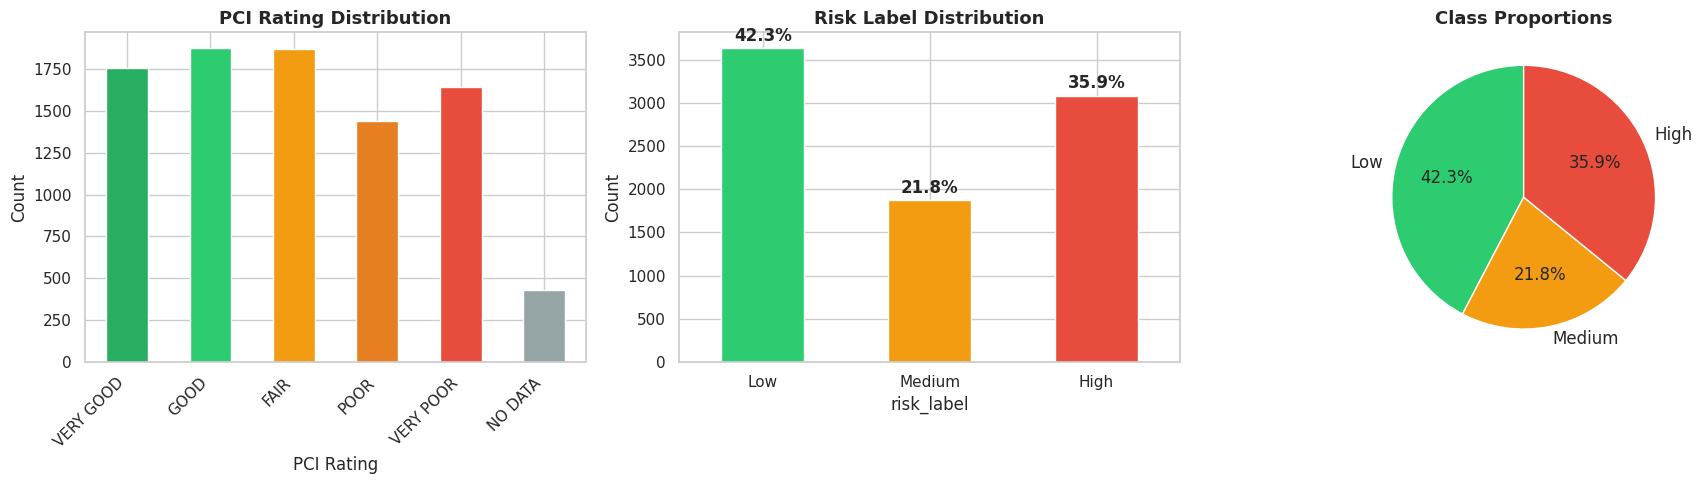


High-risk class: 35.9% — imbalance is manageable.


In [14]:
# === Class distribution visualization ===
if PCI_COL is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) PCI Rating category counts (original labels)
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR', 'NO DATA']
    cat_counts = df_pavement[PCI_COL].str.upper().str.strip().value_counts().reindex(order).dropna()
    cat_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']
    cat_counts.plot(kind='bar', ax=axes[0], color=cat_colors[:len(cat_counts)], edgecolor='white')
    axes[0].set_title('PCI Rating Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # 2) Risk label bar chart
    risk_counts = df_pavement['risk_label'].value_counts().reindex(['Low', 'Medium', 'High']).dropna()
    colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    risk_counts.plot(kind='bar', ax=axes[1], color=[colors.get(c, '#999') for c in risk_counts.index], edgecolor='white')
    axes[1].set_title('Risk Label Distribution', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    total = risk_counts.sum()
    for j, (label, count) in enumerate(risk_counts.items()):
        axes[1].text(j, count + total * 0.01, f'{count/total*100:.1f}%', ha='center', fontweight='bold')

    # 3) Pie chart
    risk_pct = risk_counts / total * 100
    axes[2].pie(risk_pct, labels=risk_pct.index, autopct='%1.1f%%',
                colors=[colors.get(c, '#999') for c in risk_pct.index], startangle=90,
                textprops={'fontsize': 12})
    axes[2].set_title('Class Proportions', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Flag imbalance
    high_pct = risk_counts.get('High', 0) / total * 100
    if high_pct < 10:
        print(f'\n*** CLASS IMBALANCE WARNING: High-risk class is only {high_pct:.1f}% ***')
        print('Recommendation: Stratified split + class weights or SMOTE.')
    else:
        print(f'\nHigh-risk class: {high_pct:.1f}% — imbalance is manageable.')


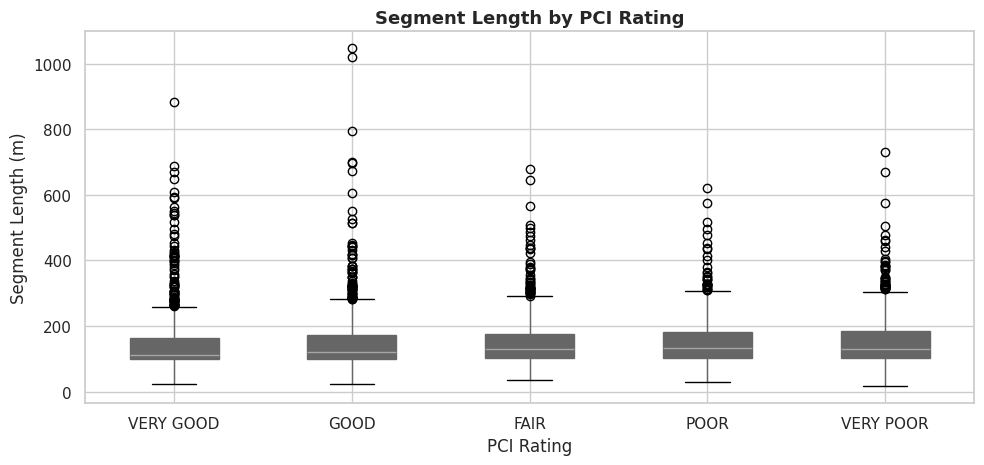

In [15]:
# === PCI Rating vs Segment Length ===
# Since PCI is categorical, check if segment length correlates with condition
if PCI_COL and 'length_(m)' in df_pavement.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_plot = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_plot['_pci'] = pd.Categorical(df_plot[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_plot.boxplot(column='length_(m)', by='_pci', ax=ax, patch_artist=True)
    ax.set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    ax.set_xlabel('PCI Rating')
    ax.set_ylabel('Segment Length (m)')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
else:
    print('No segment length column available for cross-analysis.')


---
## Part 3 — 311 Service Requests Analysis

Key tasks from the briefing:
- Identify road-related complaint types
- Handle deduplication (same pothole → many reports)
- Analyze geographic reporting bias
- Construct per-segment complaint frequency time-series

In [16]:
print(f'311 Requests shape: {df_311.shape}')
print(f'\nColumns: {list(df_311.columns)}')
print(f'\nDate range:')

# Identify date column
date_cols = [c for c in df_311.columns if 'date' in c.lower() or 'time' in c.lower() or 'created' in c.lower()]
print(f'Date columns: {date_cols}')

# Identify category/type column
cat_cols = [c for c in df_311.columns if any(kw in c.lower() for kw in ['type', 'category', 'department', 'service', 'case'])]
print(f'Category columns: {cat_cols}')

311 Requests shape: (1155936, 13)

Columns: ['Department', 'Service request type', 'Status', 'Closure reason', 'Service request open timestamp', 'Service request close date', 'Last modified timestamp', 'Address', 'Local area', 'Channel', 'Latitude', 'Longitude', 'geom']

Date range:
Date columns: ['Service request open timestamp', 'Service request close date', 'Last modified timestamp']
Category columns: ['Department', 'Service request type', 'Service request open timestamp', 'Service request close date']


In [17]:
# === Filter for road/pavement-related complaints ===
# Auto-detect the category column
CAT_COL = None
for col in df_311.columns:
    cl = col.lower()
    if any(kw in cl for kw in ['case_type', 'type', 'category', 'service_name', 'service request type', 'request type']):
        if df_311[col].dtype == 'object':
            CAT_COL = col
            break

if CAT_COL:
    print(f'Using category column: "{CAT_COL}"')
    print(f'\nTop 30 complaint categories:')
    print(df_311[CAT_COL].value_counts().head(30))
else:
    print('Could not auto-detect category column.')
    print('String columns:', [c for c in df_311.columns if df_311[c].dtype == 'object'])


Using category column: "Service request type"

Top 30 complaint categories:
Service request type
Building and Development Inquiry Case     106088
Business Licence Request Case              65843
Missed Green Bin Pickup Case               57520
Garbage Bin Request Case                   52075
City and Park Trees Maintenance Case       46267
Missed Garbage Bin Pickup Case             42362
Mayor and Council Feedback Case            42107
Abandoned Non-Recyclables-Small Case       38123
Green Bin Request Case                     30684
City Services Feedback Case                29108
Parking Enforcement Transfer Case          25831
Parking Enforcement Request Case           24227
General Feedback Case                      23232
Noise on Private Property Case             20605
Abandoned or Uninsured Vehicle Case        20045
Meter Out of Order Internal Audit Case     18708
Public Hearing Feedback Case               18640
Pothole Case                               18311
Animal Concern Case  

In [18]:
# === Filter road-related 311 requests ===
# Common keywords: pothole, road, pavement, street, sidewalk, curb, manhole
ROAD_KEYWORDS = ['pothole', 'road', 'pavement', 'street repair', 'manhole', 'sewer',
                 'curb', 'crack', 'asphalt', 'roadway', 'street light']

if CAT_COL:
    mask = df_311[CAT_COL].str.lower().str.contains('|'.join(ROAD_KEYWORDS), na=False)
    df_311_road = df_311[mask].copy()
    print(f'Road-related 311 requests: {len(df_311_road):,} / {len(df_311):,} ({len(df_311_road)/len(df_311)*100:.1f}%)')
    print(f'\nRoad-related categories:')
    print(df_311_road[CAT_COL].value_counts().head(15))
else:
    # Fallback: search across all string columns
    mask = pd.Series(False, index=df_311.index)
    for col in df_311.select_dtypes(include='object').columns:
        mask |= df_311[col].str.lower().str.contains('|'.join(ROAD_KEYWORDS), na=False)
    df_311_road = df_311[mask].copy()
    print(f'Road-related 311 requests (keyword search): {len(df_311_road):,}')

Road-related 311 requests: 60,259 / 1,155,936 (5.2%)

Road-related categories:
Service request type
Pothole Case                                        18311
Street Light Out Case                               15766
Street Repair Case                                   8527
Sewer Backup Case                                    4739
Street Light Pole Maintenance Case                   2070
Sewer Drainage and Design Inquiry Case               1476
Sewer Maintenance Hole Concern Case                  1420
Residential Street Curbside Sign Request Case        1385
Sewer Operations Inquiry Case                        1275
Sewer Construction Concern Case                      1245
Pavement Marking Maintenance Case                     794
New or Relocate Street Light Pole Case                760
Arterial St. Curbside Sign - New Request Case         719
Commercial Street Curbside Sign Request Case          496
Arterial St. Curbside Sign - Modify Request Case      466
Name: count, dtype: int64


Using 311 date column: "Service request open timestamp"


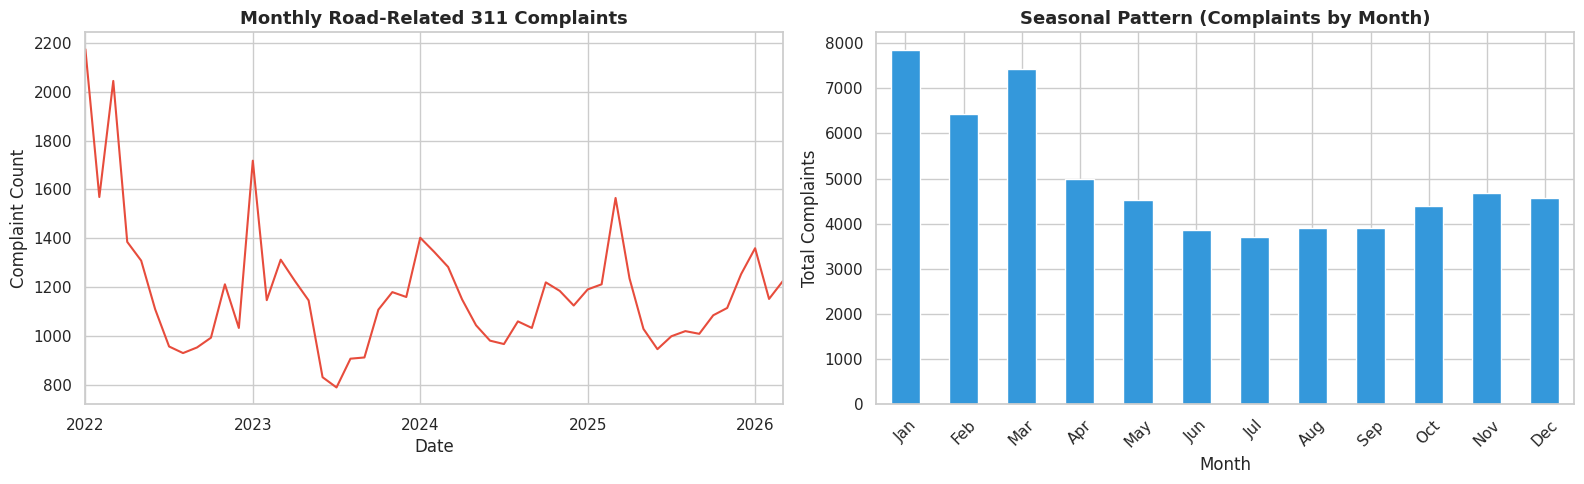

Date range: 2022-01-01 16:25:39 — 2026-03-31 04:24:36


In [20]:
# === 311 temporal analysis ===
# Parse date column
DATE_COL_311 = None
for col in df_311.columns:
    cl = col.lower()
    if ('date' in cl or 'created' in cl or 'opened' in cl or 'open' in cl or 'timestamp' in cl):
        # Prefer the 'open' timestamp over 'close' or 'modified'
        if 'close' in cl or 'modified' in cl:
            continue
        DATE_COL_311 = col
        break

# Fallback: any column with 'date' or 'timestamp'
if DATE_COL_311 is None:
    for col in df_311.columns:
        if 'date' in col.lower() or 'timestamp' in col.lower():
            DATE_COL_311 = col
            break

print(f'Using 311 date column: "{DATE_COL_311}"')

if DATE_COL_311:
    df_311_road[DATE_COL_311] = pd.to_datetime(df_311_road[DATE_COL_311], errors='coerce', utc=True).dt.tz_localize(None)
    df_311_road = df_311_road.dropna(subset=[DATE_COL_311])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Monthly complaint volume
    monthly = df_311_road.set_index(DATE_COL_311).resample('M').size()
    monthly.plot(ax=axes[0], color='#e74c3c', linewidth=1.5)
    axes[0].set_title('Monthly Road-Related 311 Complaints', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Complaint Count')

    # Seasonal pattern (month-of-year)
    df_311_road['month'] = df_311_road[DATE_COL_311].dt.month
    seasonal = df_311_road.groupby('month').size()
    seasonal.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
    axes[1].set_title('Seasonal Pattern (Complaints by Month)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Total Complaints')
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)

    plt.tight_layout()
    plt.show()

    print(f'Date range: {df_311_road[DATE_COL_311].min()} — {df_311_road[DATE_COL_311].max()}')
else:
    print('No date column found in 311 data.')
    print(f'Available columns: {list(df_311.columns)}')


Geographic columns in 311 data: ['Latitude', 'Longitude', 'geom']


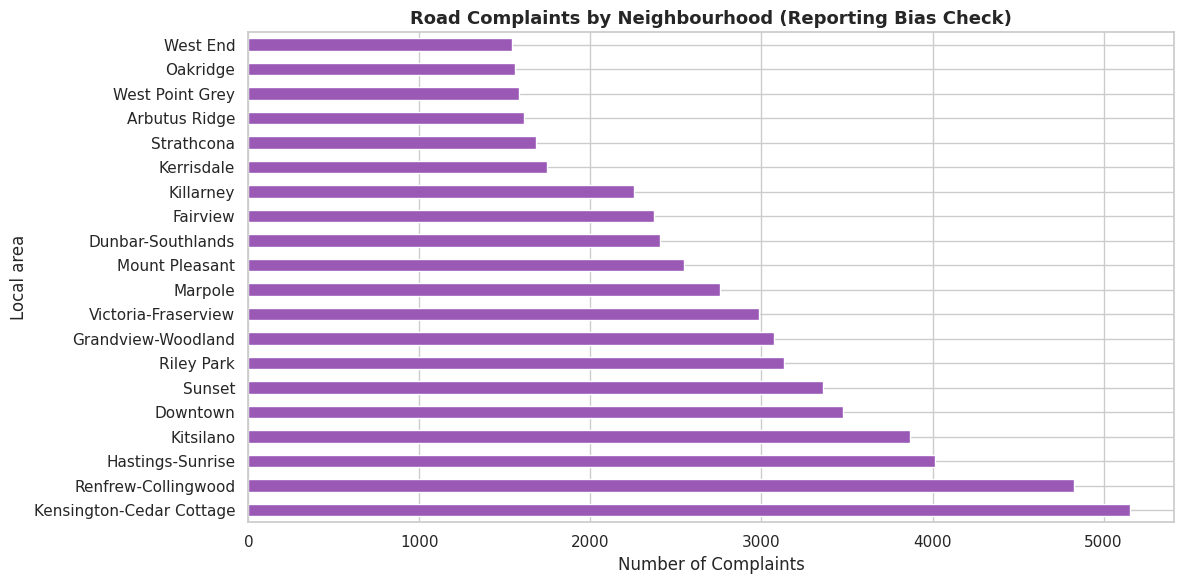

Note: Higher complaint counts may reflect reporting bias, not worse road conditions.


In [21]:
# === Deduplication analysis ===
# Per the briefing: same pothole can generate dozens of reports
# Check for spatial/temporal clustering

geo_cols_311 = [c for c in df_311_road.columns if 'lat' in c.lower() or 'lon' in c.lower() or 'geo' in c.lower() or 'local_area' in c.lower() or 'neighbourhood' in c.lower()]
print(f'Geographic columns in 311 data: {geo_cols_311}')

# If we have a neighborhood/local_area column, show distribution
area_col = None
for col in df_311_road.columns:
    if any(kw in col.lower() for kw in ['local_area', 'neighbourhood', 'neighborhood', 'area']):
        area_col = col
        break

if area_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    area_counts = df_311_road[area_col].value_counts().head(20)
    area_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title('Road Complaints by Neighbourhood (Reporting Bias Check)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Complaints')
    plt.tight_layout()
    # plt.savefig('../EDA/311_neighbourhood_bias.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Note: Higher complaint counts may reflect reporting bias, not worse road conditions.')

---
## Part 4 — Weather Data Analysis

Key features to engineer (from the briefing):
1. **Freeze-thaw cycle count**: days where min temp crosses 0°C
2. **Cumulative precipitation**: rolling sum
3. **Maximum single-day rainfall**

Vancouver freeze-thaw season: Dec–Mar; peak rainfall: Oct–Mar.

In [22]:
print(f'Weather data shape: {df_weather.shape}')
print(f'\nColumns: {list(df_weather.columns)}')
print(f'\nFirst 3 rows:')
display(df_weather.head(3))

Weather data shape: (2557, 31)

Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']

First 3 rows:


,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-01,2019,1,1,NaN,5.3,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
1,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-02,2019,1,2,NaN,5.5,...,0.0,T,3.4,NaN,NaN,NaN,6.0,NaN,41.0,NaN
2,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-03,2019,1,3,NaN,9.5,...,0.0,NaN,54.8,NaN,NaN,NaN,14.0,NaN,54.0,NaN


In [23]:
# === Parse weather columns ===
# Environment Canada daily CSV columns:
# 'Date/Time', 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Precip (mm)', etc.

# Auto-detect date column
date_col_w = None
for col in df_weather.columns:
    if 'date' in col.lower():
        date_col_w = col
        break

if date_col_w:
    df_weather[date_col_w] = pd.to_datetime(df_weather[date_col_w], errors='coerce')
    df_weather = df_weather.dropna(subset=[date_col_w]).sort_values(date_col_w)
    print(f'Date range: {df_weather[date_col_w].min()} — {df_weather[date_col_w].max()}')

# Auto-detect temperature and precipitation columns
# IMPORTANT: Exclude 'Flag' columns — they are quality markers, not data
temp_min_col = None
temp_max_col = None
precip_col = None

for col in df_weather.columns:
    cl = col.lower()
    if 'flag' in cl:
        continue  # Skip all flag columns
    if 'min' in cl and 'temp' in cl:
        temp_min_col = col
    elif 'max' in cl and 'temp' in cl:
        temp_max_col = col
    elif 'total precip' in cl:
        precip_col = col

# Fallback for precip
if precip_col is None:
    for col in df_weather.columns:
        if 'precip' in col.lower() and 'flag' not in col.lower():
            precip_col = col
            break

print(f'Min Temp column: {temp_min_col}')
print(f'Max Temp column: {temp_max_col}')
print(f'Precipitation column: {precip_col}')

# Quick sanity check
for col in [temp_min_col, temp_max_col, precip_col]:
    if col:
        nn = df_weather[col].notna().sum()
        print(f'  {col}: {nn}/{len(df_weather)} non-null values')


Date range: 2019-01-01 00:00:00 — 2025-12-31 00:00:00
Min Temp column: Min Temp (°C)
Max Temp column: Max Temp (°C)
Precipitation column: Total Precip (mm)
  Min Temp (°C): 2500/2557 non-null values
  Max Temp (°C): 2500/2557 non-null values
  Total Precip (mm): 2547/2557 non-null values


In [24]:
# === Missing value analysis for weather ===
if date_col_w:
    weather_key_cols = [c for c in [temp_min_col, temp_max_col, precip_col] if c is not None]

    # Check for gaps in the date series
    date_range = pd.date_range(df_weather[date_col_w].min(), df_weather[date_col_w].max(), freq='D')
    missing_dates = date_range.difference(df_weather[date_col_w])
    print(f'Missing dates in time series: {len(missing_dates)}')
    if len(missing_dates) > 0 and len(missing_dates) <= 20:
        print(f'Missing dates: {list(missing_dates.strftime("%Y-%m-%d"))}')
    elif len(missing_dates) > 20:
        print(f'First 10 missing: {list(missing_dates[:10].strftime("%Y-%m-%d"))}')

    # Missing values in key columns (actual data, not flags)
    for col in weather_key_cols:
        vals = pd.to_numeric(df_weather[col], errors='coerce')
        missing = vals.isna().sum()
        # Check for consecutive missing stretches
        is_missing = vals.isna()
        if is_missing.any():
            groups = (is_missing != is_missing.shift()).cumsum()
            streak_lengths = is_missing.groupby(groups).sum()
            max_streak = int(streak_lengths.max())
            print(f'  {col}: {missing} missing ({missing/len(df_weather)*100:.1f}%), max consecutive gap: {max_streak} days')
            if max_streak > 3:
                print(f'    WARNING: Gaps > 3 days — consider monthly climatological averages for imputation.')
        else:
            print(f'  {col}: 0 missing')


Missing dates in time series: 0
  Min Temp (°C): 57 missing (2.2%), max consecutive gap: 2 days
  Max Temp (°C): 57 missing (2.2%), max consecutive gap: 2 days
  Total Precip (mm): 10 missing (0.4%), max consecutive gap: 2 days


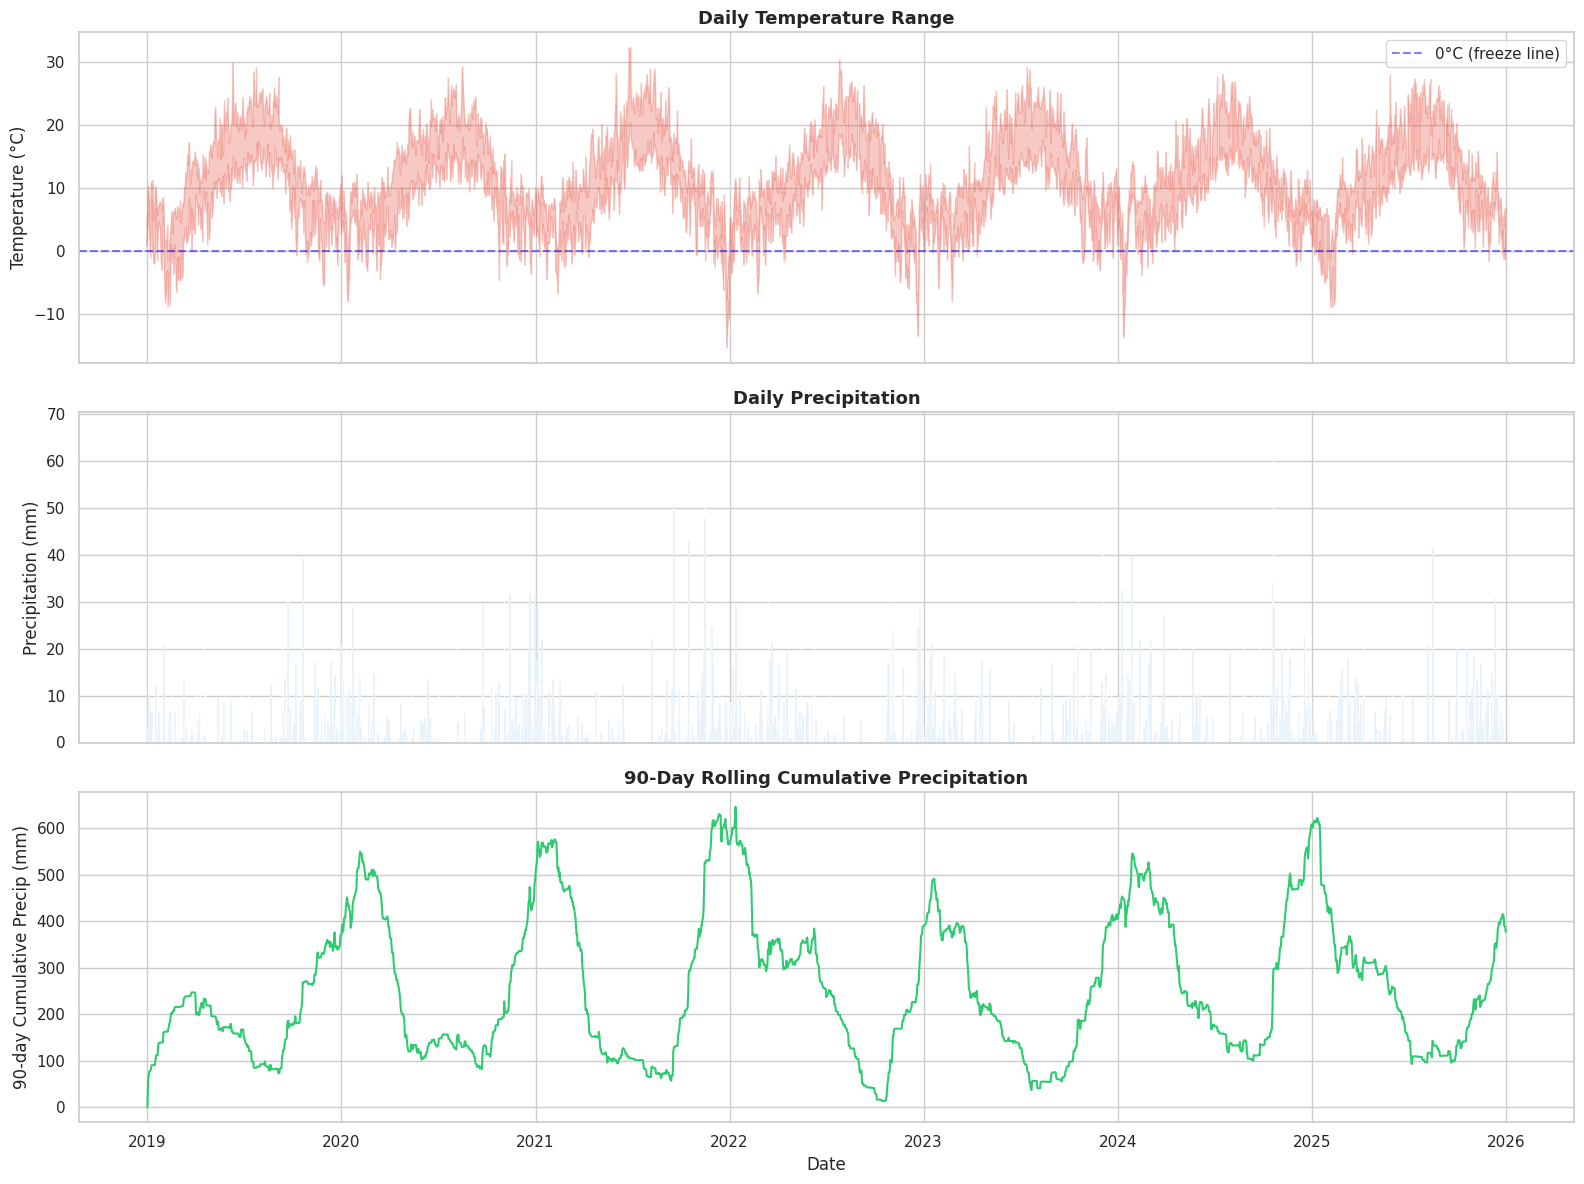

In [25]:
# === Weather time-series visualization ===
if date_col_w and temp_min_col and precip_col:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # 1) Temperature range
    if temp_max_col:
        axes[0].fill_between(df_weather[date_col_w],
                             pd.to_numeric(df_weather[temp_min_col], errors='coerce'),
                             pd.to_numeric(df_weather[temp_max_col], errors='coerce'),
                             alpha=0.3, color='#e74c3c')
    axes[0].axhline(0, color='blue', linestyle='--', alpha=0.5, label='0°C (freeze line)')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title('Daily Temperature Range', fontsize=13, fontweight='bold')
    axes[0].legend()

    # 2) Daily precipitation
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce')
    axes[1].bar(df_weather[date_col_w], precip_vals, width=1, color='#3498db', alpha=0.7)
    axes[1].set_ylabel('Precipitation (mm)')
    axes[1].set_title('Daily Precipitation', fontsize=13, fontweight='bold')

    # 3) 90-day rolling cumulative precipitation
    rolling_precip = precip_vals.rolling(90, min_periods=1).sum()
    axes[2].plot(df_weather[date_col_w], rolling_precip, color='#2ecc71', linewidth=1.5)
    axes[2].set_ylabel('90-day Cumulative Precip (mm)')
    axes[2].set_title('90-Day Rolling Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    # plt.savefig('../EDA/weather_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

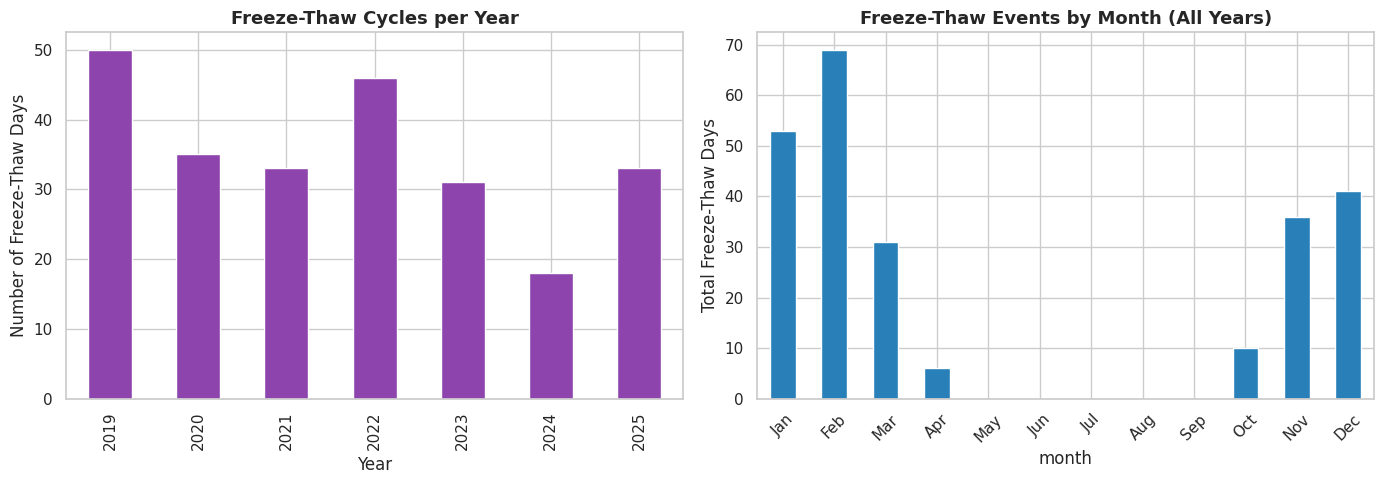

Total freeze-thaw days: 246
Mean per year: 35.1
Peak months: Dec, Jan, Feb, Mar (as expected for Vancouver)


In [26]:
# === Freeze-thaw cycle analysis ===
if temp_min_col and temp_max_col and date_col_w:
    tmin = pd.to_numeric(df_weather[temp_min_col], errors='coerce')
    tmax = pd.to_numeric(df_weather[temp_max_col], errors='coerce')

    # A freeze-thaw day: min temp < 0 AND max temp > 0
    df_weather['freeze_thaw'] = (tmin < 0) & (tmax > 0)

    # Count per year
    df_weather['year'] = df_weather[date_col_w].dt.year
    ft_by_year = df_weather.groupby('year')['freeze_thaw'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Annual freeze-thaw cycles
    ft_by_year.plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='white')
    axes[0].set_title('Freeze-Thaw Cycles per Year', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Number of Freeze-Thaw Days')
    axes[0].set_xlabel('Year')

    # Monthly distribution of freeze-thaw events
    df_weather['month'] = df_weather[date_col_w].dt.month
    ft_by_month = df_weather.groupby('month')['freeze_thaw'].sum()
    ft_by_month.plot(kind='bar', ax=axes[1], color='#2980b9', edgecolor='white')
    axes[1].set_title('Freeze-Thaw Events by Month (All Years)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Total Freeze-Thaw Days')
    axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

    plt.tight_layout()
    # plt.savefig('../EDA/freeze_thaw_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 90-day rolling freeze-thaw count
    df_weather['ft_rolling_90d'] = df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum()
    print(f'Total freeze-thaw days: {df_weather["freeze_thaw"].sum()}')
    print(f'Mean per year: {ft_by_year.mean():.1f}')
    print(f'Peak months: Dec, Jan, Feb, Mar (as expected for Vancouver)')

---
## Part 5 — Infrastructure Data Analysis

Infrastructure is represented by 4 local datasets:
- **Public Streets** — street classification (Arterial/Collector/Residential)
- **Right-of-Way Widths** — road width measurements
- **Traffic Count Locations** — traffic monitoring points
- **City Repair Projects** — recent/upcoming maintenance (repair history proxy)

In [27]:
import ast

def parse_geo_point(geo_str):
    try:
        d = ast.literal_eval(geo_str)
        return d['lat'], d['lon']
    except:
        return np.nan, np.nan

def add_lat_lon(df, col='geo_point_2d'):
    if col in df.columns:
        df[['lat', 'lon']] = df[col].apply(lambda x: pd.Series(parse_geo_point(x)))
    return df

df_streets = add_lat_lon(df_streets)
df_row = add_lat_lon(df_row)
df_traffic = add_lat_lon(df_traffic)
df_repairs = add_lat_lon(df_repairs)

print(f'Streets: {df_streets.shape} — types: {df_streets["streetuse"].value_counts().to_dict()}')
print(f'ROW Widths: {df_row.shape} — range: {df_row["width"].min()}-{df_row["width"].max()} ft, mean: {df_row["width"].mean():.1f} ft')
print(f'Traffic: {df_traffic.shape}')
print(f'Repairs: {df_repairs.shape} — columns: {list(df_repairs.columns)}')


Streets: (1710, 6) — types: {'Residential': 855, 'Arterial': 684, 'Collector': 171}
ROW Widths: (2690, 5) — range: 7.0-66.0 ft, mean: 37.1 ft
Traffic: (670, 5)
Repairs: (40, 8) — columns: ['expected_completion_date', 'location', 'project_title', 'url_link', 'geom', 'geo_point_2d', 'lat', 'lon']


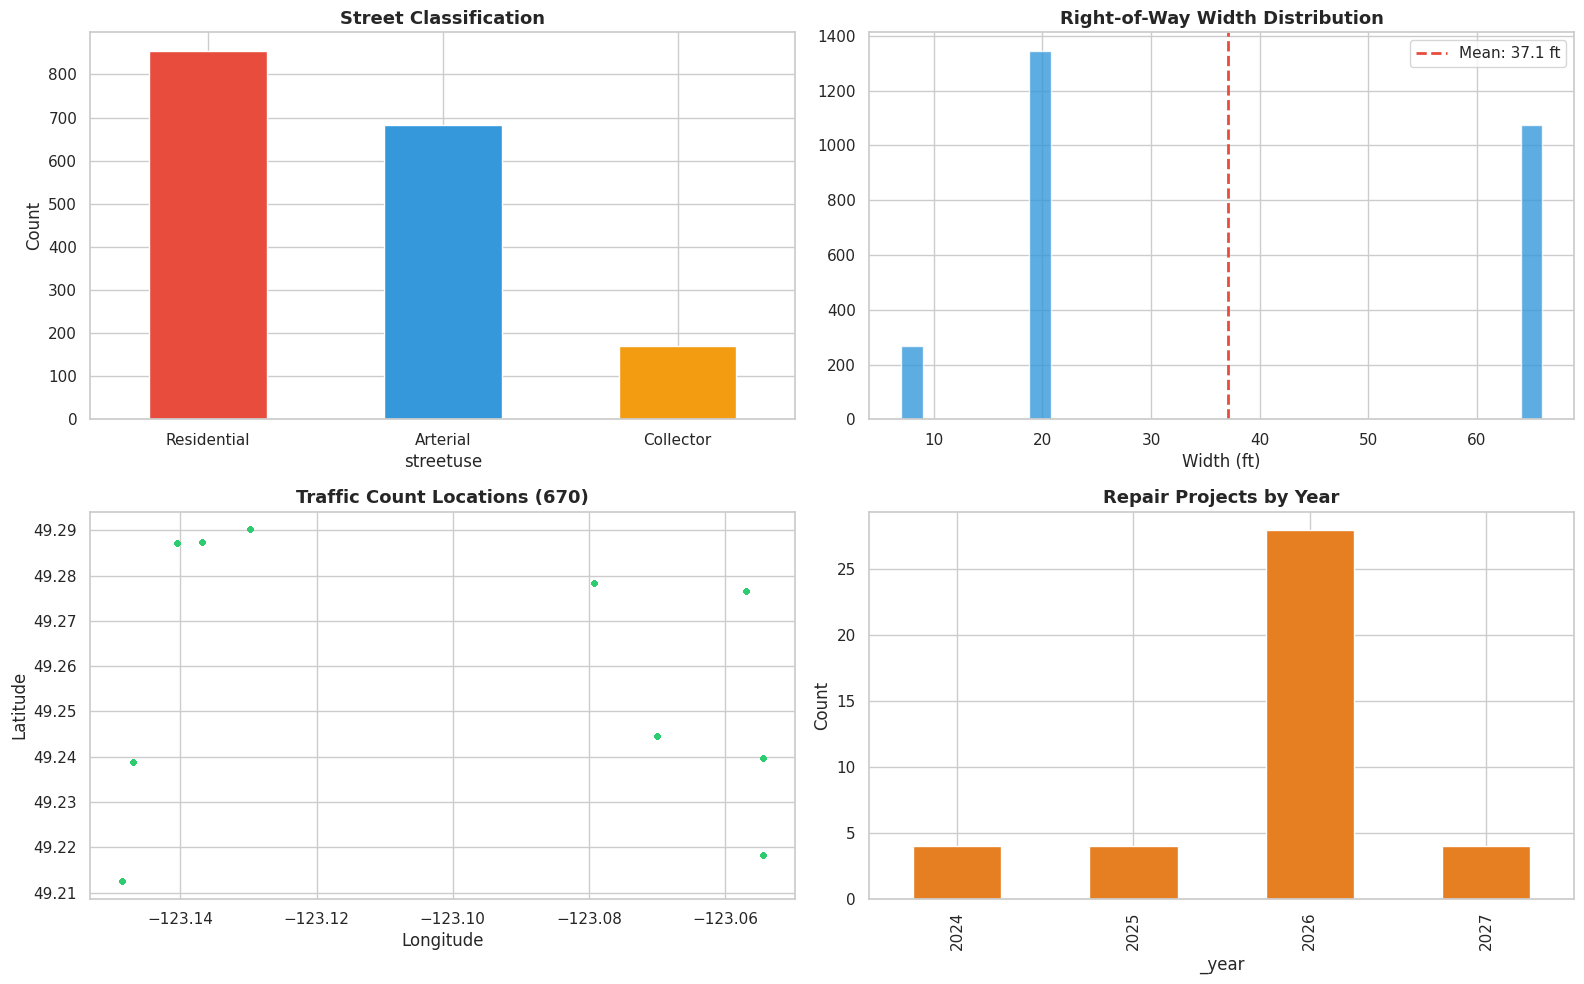

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Street classification
df_streets['streetuse'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#e74c3c','#3498db','#f39c12'], edgecolor='white')
axes[0,0].set_title('Street Classification', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# 2) ROW width distribution
axes[0,1].hist(df_row['width'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0,1].axvline(df_row['width'].mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Mean: {df_row["width"].mean():.1f} ft')
axes[0,1].set_title('Right-of-Way Width Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Width (ft)')
axes[0,1].legend()

# 3) Traffic count locations
tc = df_traffic.dropna(subset=['lat','lon'])
axes[1,0].scatter(tc['lon'], tc['lat'], alpha=0.5, s=10, c='#2ecc71')
axes[1,0].set_title(f'Traffic Count Locations ({len(tc)})', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Longitude')
axes[1,0].set_ylabel('Latitude')

# 4) Repair projects by year
if 'expected_completion_date' in df_repairs.columns:
    df_repairs['_year'] = pd.to_datetime(df_repairs['expected_completion_date'], errors='coerce').dt.year
    df_repairs['_year'].dropna().value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='white')
    axes[1,1].set_title('Repair Projects by Year', fontsize=13, fontweight='bold')
    axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


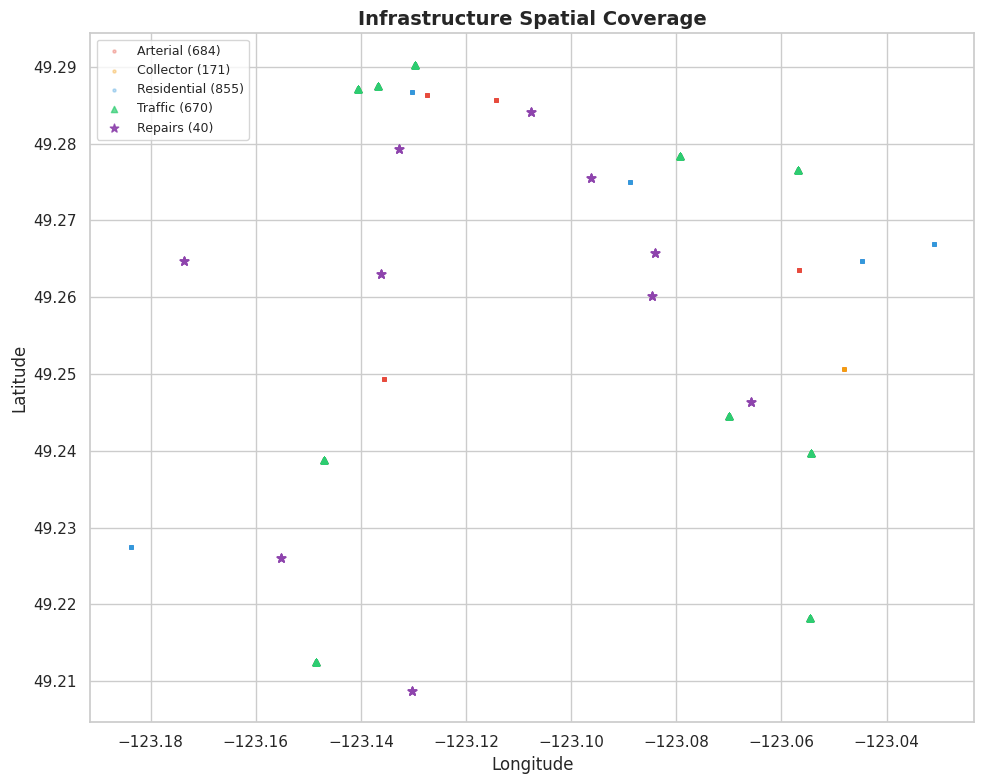

In [29]:
# === Spatial coverage ===
fig, ax = plt.subplots(figsize=(10, 8))
for stype, color in [('Arterial','#e74c3c'),('Collector','#f39c12'),('Residential','#3498db')]:
    s = df_streets[df_streets['streetuse']==stype].dropna(subset=['lat','lon'])
    ax.scatter(s['lon'], s['lat'], s=5, alpha=0.3, c=color, label=f'{stype} ({len(s)})')
tc = df_traffic.dropna(subset=['lat','lon'])
ax.scatter(tc['lon'], tc['lat'], s=20, c='#2ecc71', marker='^', alpha=0.7, label=f'Traffic ({len(tc)})')
rp = df_repairs.dropna(subset=['lat','lon'])
ax.scatter(rp['lon'], rp['lat'], s=40, c='#8e44ad', marker='*', alpha=0.9, label=f'Repairs ({len(rp)})')
ax.set_title('Infrastructure Spatial Coverage', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


---
## Part 6 — Cross-Dataset Join Validation

**Critical check from the briefing:** All 4 datasets are joined on road segment ID. We must verify:
1. ID format consistency (capitalization, prefixes, null values)
2. Join coverage (how many segments can be matched)
3. Silent data loss during merge

In [30]:
print('=== Join Key Analysis ===')
print()
print('Pavement: Road Name + From/To Street')
if 'Road Name' in df_pavement.columns:
    print(f'  Sample: {df_pavement["Road Name"].head(3).tolist()}')
print('\nPublic Streets: hblock (hundred-block address)')
print(f'  Sample: {df_streets["hblock"].head(3).tolist()}')
print('\n311 Requests: Address text + lat/lon')
print('\nWeather: City-wide (temporal join only)')
print('\n=== JOIN STRATEGY ===')
print('  Pavement <-> Streets:   Street name match')
print('  Pavement <-> ROW:       Spatial (nearest point)')
print('  Pavement <-> Traffic:   Spatial (nearest count station)')
print('  Pavement <-> 311:       Spatial (complaint -> segment)')
print('  Pavement <-> Weather:   Temporal (city-wide)')
print('  Pavement <-> Repairs:   Street name match')


=== Join Key Analysis ===

Pavement: Road Name + From/To Street
  Sample: ['54TH AV', '50TH AV', '6TH AV']

Public Streets: hblock (hundred-block address)
  Sample: ['2700 E 22ND AV', '700 W HASTINGS ST', '1200 ROBSON ST']

311 Requests: Address text + lat/lon

Weather: City-wide (temporal join only)

=== JOIN STRATEGY ===
  Pavement <-> Streets:   Street name match
  Pavement <-> ROW:       Spatial (nearest point)
  Pavement <-> Traffic:   Spatial (nearest count station)
  Pavement <-> 311:       Spatial (complaint -> segment)
  Pavement <-> Weather:   Temporal (city-wide)
  Pavement <-> Repairs:   Street name match


In [31]:
# === Test street name matching ===
import re
def extract_street(hblock):
    if pd.isna(hblock): return np.nan
    return re.sub(r'^\d+\s+', '', str(hblock)).strip().upper()

if 'Road Name' in df_pavement.columns and 'hblock' in df_streets.columns:
    pav_names = set(df_pavement['Road Name'].dropna().str.upper().str.strip())
    st_names = set(df_streets['hblock'].apply(extract_street).dropna())
    overlap = pav_names & st_names
    print(f'Pavement streets:    {len(pav_names)}')
    print(f'Public Streets:      {len(st_names)}')
    print(f'Overlap:             {len(overlap)} ({len(overlap)/max(len(pav_names),1)*100:.1f}%)')
    if overlap: print(f'Sample: {list(overlap)[:8]}')


Pavement streets:    808
Public Streets:      10
Overlap:             4 (0.5%)
Sample: ['NANAIMO ST', 'CASSIAR ST', 'HARO ST', 'ROBSON ST']


In [32]:
# === Data Integration Summary ===
print(f'Base: Pavement ({len(df_pavement)} segments)')
print(f'  + Street type:   name match with Streets ({len(df_streets)} records)')
print(f'  + Road width:    spatial join with ROW ({len(df_row)} points)')
print(f'  + Traffic:       spatial join with Traffic ({len(df_traffic)} stations)')
print(f'  + Repair history: name match with Repairs ({len(df_repairs)} projects)')
print(f'  + Complaints:    spatial join with 311 ({len(df_311_road)} road complaints)')
print(f'  + Weather:       temporal join, city-wide ({len(df_weather)} daily records)')


Base: Pavement (9016 segments)
  + Street type:   name match with Streets (1710 records)
  + Road width:    spatial join with ROW (2690 points)
  + Traffic:       spatial join with Traffic (670 stations)
  + Repair history: name match with Repairs (40 projects)
  + Complaints:    spatial join with 311 (60259 road complaints)
  + Weather:       temporal join, city-wide (2557 daily records)


---
## Part 7 — Feature Engineering Preview

Preview the key engineered features that will feed into the 4-branch fusion model:
1. **PCI branch**: PCI score + distress sub-scores (static per segment)
2. **Weather branch (BiLSTM input)**: 90-day rolling freeze-thaw count, cumulative precipitation, max single-day rainfall
3. **311 branch (BiLSTM input)**: Per-segment complaint frequency (30/90-day rolling windows)
4. **Infrastructure branch**: Segment age, surface material (one-hot), repair history flag

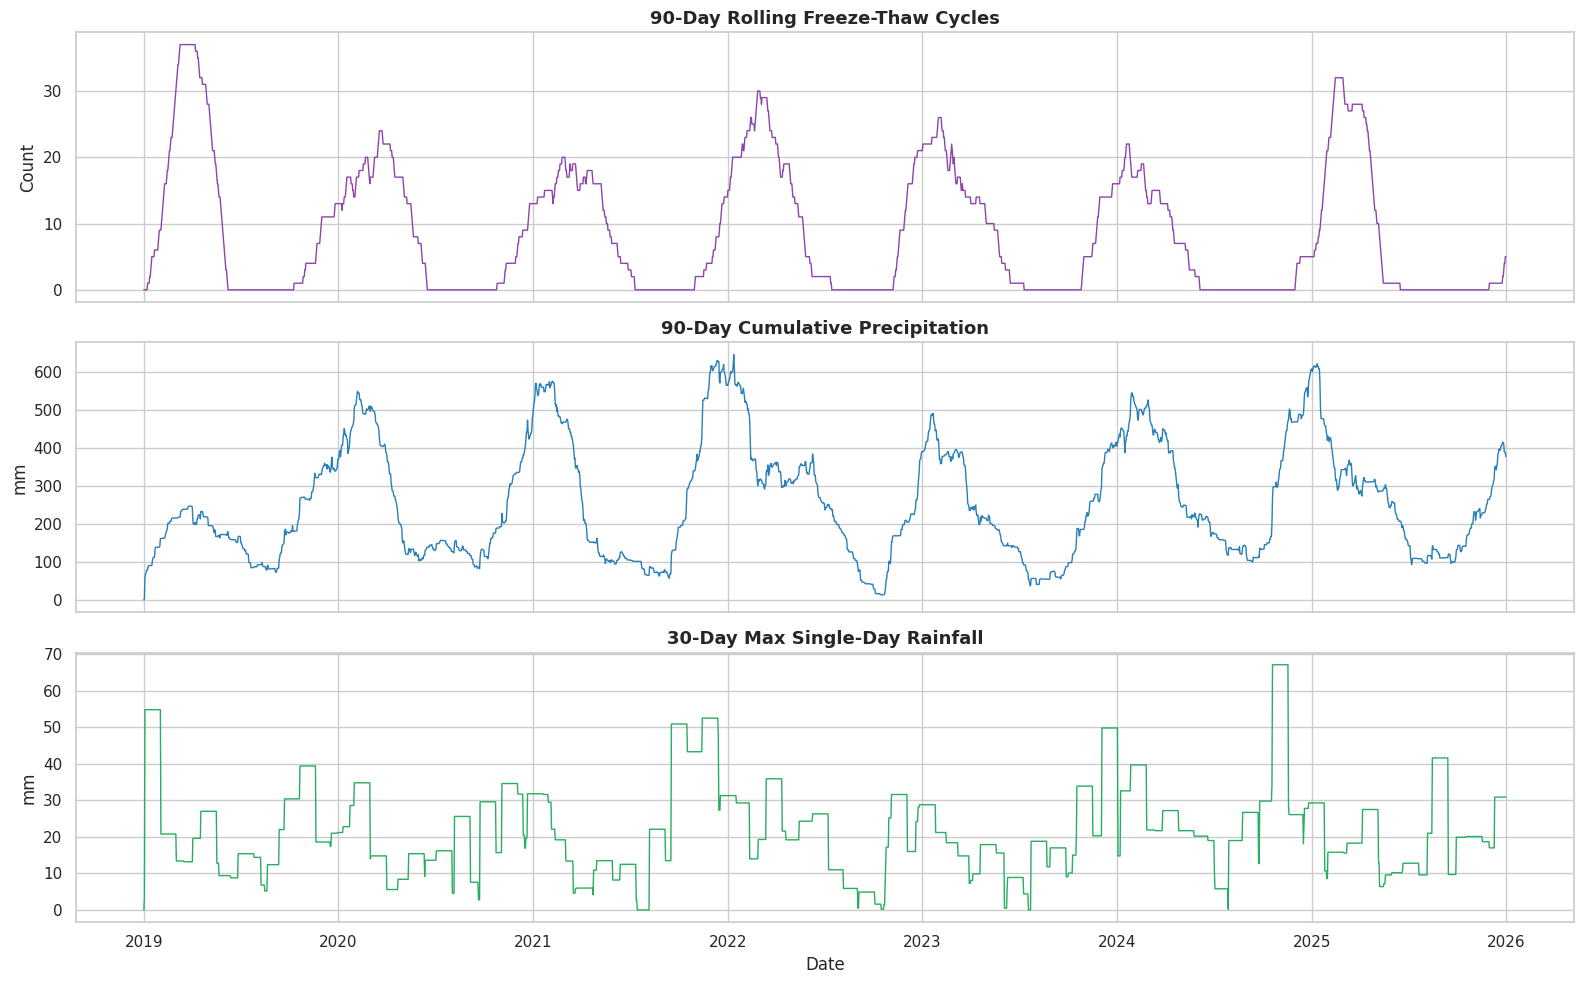

Weather features summary:
                                date  freeze_thaw_90d  cumul_precip_90d  \
count                           2557          2557.00           2557.00   
mean   2022-07-01 23:59:59.999999744             8.50            256.98   
min              2019-01-01 00:00:00             0.00              0.00   
25%              2020-10-01 00:00:00             0.00            132.60   
50%              2022-07-02 00:00:00             4.00            218.60   
75%              2024-04-01 00:00:00            16.00            363.70   
max              2025-12-31 00:00:00            37.00            646.30   
std                              NaN             9.63            150.18   

       max_precip_30d  
count         2557.00  
mean            22.11  
min              0.00  
25%             13.50  
50%             19.90  
75%             29.30  
max             67.10  
std             12.69  


In [33]:
# === Weather feature engineering preview ===
if date_col_w and precip_col and temp_min_col and temp_max_col:
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce').fillna(0)

    weather_features = pd.DataFrame({
        'date': df_weather[date_col_w],
        'freeze_thaw_90d': df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum(),
        'cumul_precip_90d': precip_vals.rolling(90, min_periods=1).sum(),
        'max_precip_30d': precip_vals.rolling(30, min_periods=1).max(),
    })

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(weather_features['date'], weather_features['freeze_thaw_90d'], color='#8e44ad', linewidth=1)
    axes[0].set_ylabel('Count')
    axes[0].set_title('90-Day Rolling Freeze-Thaw Cycles', fontsize=13, fontweight='bold')

    axes[1].plot(weather_features['date'], weather_features['cumul_precip_90d'], color='#2980b9', linewidth=1)
    axes[1].set_ylabel('mm')
    axes[1].set_title('90-Day Cumulative Precipitation', fontsize=13, fontweight='bold')

    axes[2].plot(weather_features['date'], weather_features['max_precip_30d'], color='#27ae60', linewidth=1)
    axes[2].set_ylabel('mm')
    axes[2].set_title('30-Day Max Single-Day Rainfall', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    # plt.savefig('../EDA/weather_features_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Weather features summary:')
    print(weather_features.describe().round(2))

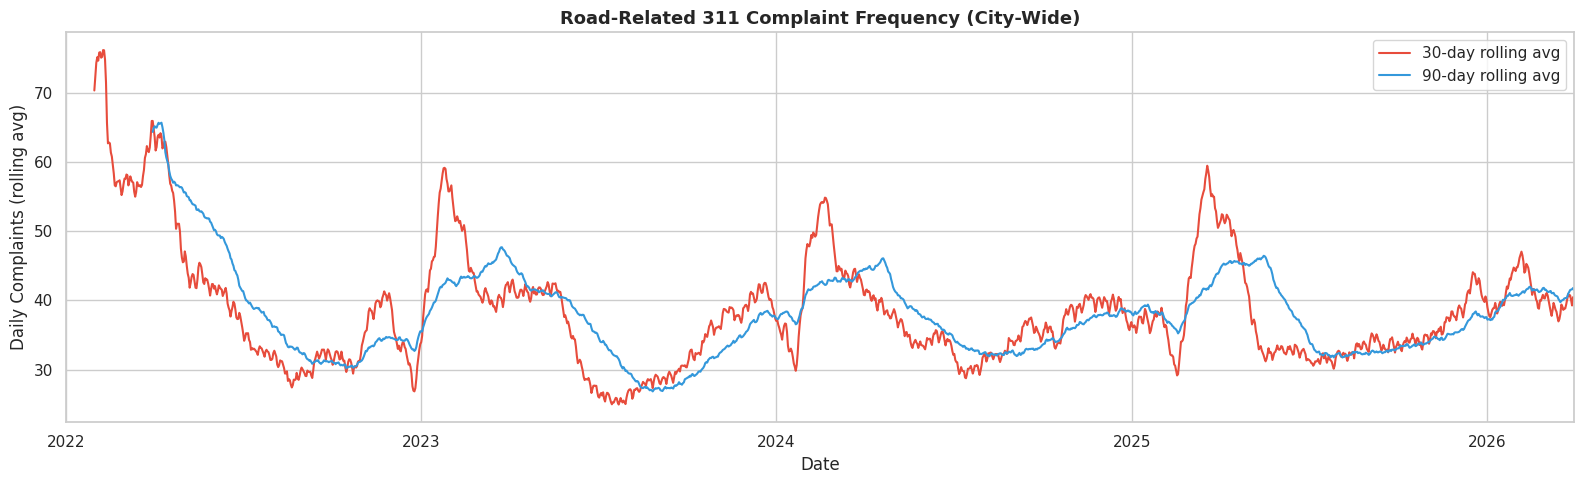

Total road-related complaints: 60,259
Average daily complaints: 38.9


In [34]:
# === 311 complaint frequency time-series preview ===
# Per the briefing: aggregate by segment + 7-day window to handle deduplication

if DATE_COL_311:
    # Overall: show 30-day and 90-day rolling complaint frequency (city-wide)
    daily_complaints = df_311_road.set_index(DATE_COL_311).resample('D').size()

    fig, ax = plt.subplots(figsize=(16, 5))
    daily_complaints.rolling(30).mean().plot(ax=ax, label='30-day rolling avg', color='#e74c3c', linewidth=1.5)
    daily_complaints.rolling(90).mean().plot(ax=ax, label='90-day rolling avg', color='#3498db', linewidth=1.5)
    ax.set_title('Road-Related 311 Complaint Frequency (City-Wide)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Complaints (rolling avg)')
    ax.set_xlabel('Date')
    ax.legend()

    plt.tight_layout()
    # plt.savefig('../EDA/311_frequency_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total road-related complaints: {len(df_311_road):,}')
    print(f'Average daily complaints: {daily_complaints.mean():.1f}')

---
## Part 8 — Correlation Analysis

Examine correlations between available numeric features to preview feature interactions.

311 monthly range: 2022-01-31 00:00:00 to 2026-03-31 00:00:00 (51 months)
Weather monthly range: 2019-01-31 00:00:00 to 2025-12-31 00:00:00 (84 months)
Overlapping months: 48


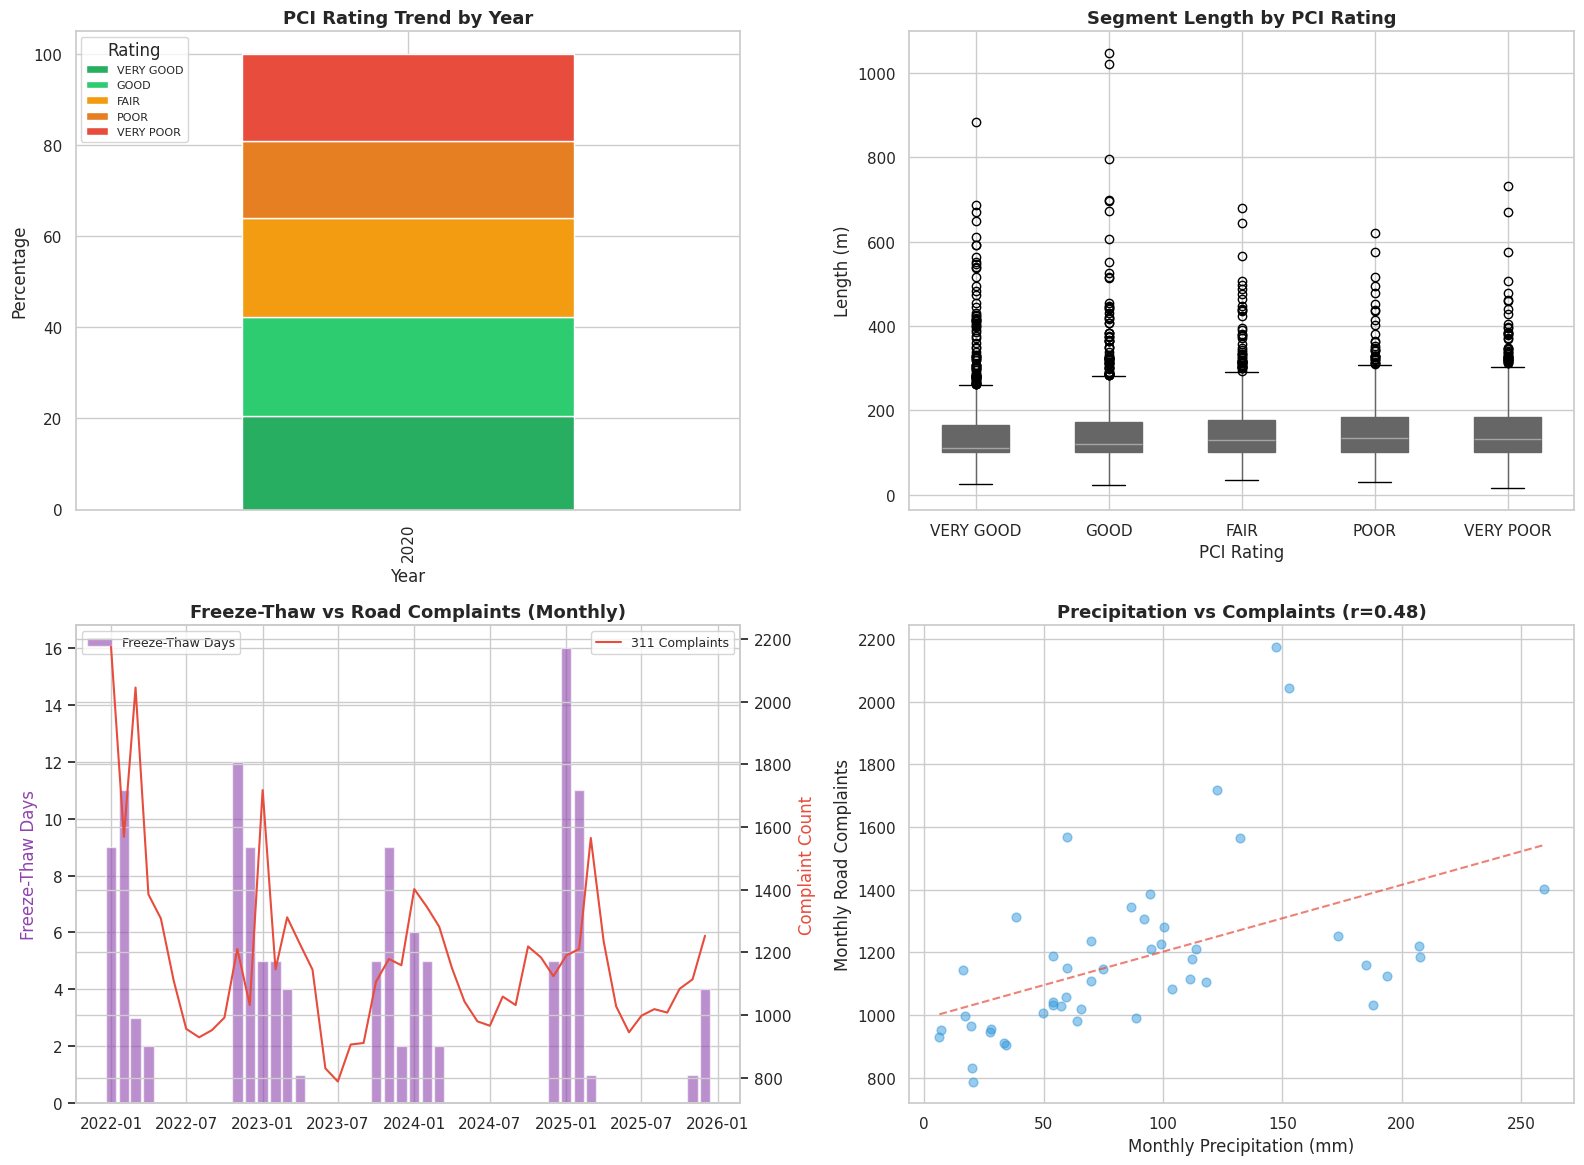

In [35]:
# === Part 8: Cross-Dataset Analysis ===

# Ensure date columns are timezone-naive datetime for consistent resampling
if DATE_COL_311 and DATE_COL_311 in df_311_road.columns:
    df_311_road[DATE_COL_311] = pd.to_datetime(df_311_road[DATE_COL_311], errors='coerce', utc=True).dt.tz_localize(None)
if date_col_w and date_col_w in df_weather.columns:
    df_weather[date_col_w] = pd.to_datetime(df_weather[date_col_w], errors='coerce')
    if df_weather[date_col_w].dt.tz is not None:
        df_weather[date_col_w] = df_weather[date_col_w].dt.tz_localize(None)

# Build monthly series
complaints_monthly = None
weather_monthly_ft = None
precip_monthly = None

if DATE_COL_311:
    tmp = df_311_road.dropna(subset=[DATE_COL_311]).copy()
    tmp = tmp.set_index(DATE_COL_311).sort_index()
    complaints_monthly = tmp.resample('M').size()
    print(f'311 monthly range: {complaints_monthly.index.min()} to {complaints_monthly.index.max()} ({len(complaints_monthly)} months)')

if date_col_w and 'freeze_thaw' in df_weather.columns:
    tmp_w = df_weather.dropna(subset=[date_col_w]).copy()
    tmp_w = tmp_w.set_index(date_col_w).sort_index()
    weather_monthly_ft = tmp_w['freeze_thaw'].resample('M').sum()
    if precip_col:
        precip_monthly = pd.to_numeric(tmp_w[precip_col], errors='coerce').resample('M').sum()
    print(f'Weather monthly range: {weather_monthly_ft.index.min()} to {weather_monthly_ft.index.max()} ({len(weather_monthly_ft)} months)')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1) PCI Rating by Year ---
if PCI_COL and 'Year' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    ct = pd.crosstab(df_pav_clean['Year'], df_pav_clean[PCI_COL].str.upper().str.strip(), normalize='index') * 100
    ct = ct[[c for c in order if c in ct.columns]]
    ct.plot(kind='bar', stacked=True, ax=axes[0, 0],
            color=['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
    axes[0, 0].set_title('PCI Rating Trend by Year', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage')
    axes[0, 0].legend(title='Rating', fontsize=8, loc='upper left')

# --- 2) Segment Length by PCI Rating ---
if PCI_COL and 'length_(m)' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_pav_clean['_pci'] = pd.Categorical(df_pav_clean[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_pav_clean.boxplot(column='length_(m)', by='_pci', ax=axes[0, 1], patch_artist=True)
    axes[0, 1].set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('PCI Rating')
    axes[0, 1].set_ylabel('Length (m)')
    plt.sca(axes[0, 1])
    plt.suptitle('')

# --- 3) Freeze-Thaw vs 311 Complaints ---
if weather_monthly_ft is not None and complaints_monthly is not None:
    # Use merge on Period to avoid timezone/exact-timestamp mismatch
    df_merge = pd.DataFrame({
        'freeze_thaw': weather_monthly_ft.values,
        'month': weather_monthly_ft.index.to_period('M')
    }).merge(
        pd.DataFrame({
            'complaints': complaints_monthly.values,
            'month': complaints_monthly.index.to_period('M')
        }),
        on='month', how='inner'
    )
    print(f'Overlapping months: {len(df_merge)}')
    if len(df_merge) > 0:
        ax3 = axes[1, 0]
        months = df_merge['month'].dt.to_timestamp()
        ax3.bar(months, df_merge['freeze_thaw'], width=25, alpha=0.6, color='#8e44ad', label='Freeze-Thaw Days')
        ax3b = ax3.twinx()
        ax3b.plot(months, df_merge['complaints'], color='#e74c3c', linewidth=1.5, label='311 Complaints')
        ax3.set_title('Freeze-Thaw vs Road Complaints (Monthly)', fontsize=13, fontweight='bold')
        ax3.set_ylabel('Freeze-Thaw Days', color='#8e44ad')
        ax3b.set_ylabel('Complaint Count', color='#e74c3c')
        ax3.legend(loc='upper left', fontsize=9)
        ax3b.legend(loc='upper right', fontsize=9)
    else:
        axes[1, 0].text(0.5, 0.5, 'No overlapping months found', ha='center', va='center')

# --- 4) Precipitation vs 311 Complaints ---
if precip_monthly is not None and complaints_monthly is not None:
    df_merge2 = pd.DataFrame({
        'precip': precip_monthly.values,
        'month': precip_monthly.index.to_period('M')
    }).merge(
        pd.DataFrame({
            'complaints': complaints_monthly.values,
            'month': complaints_monthly.index.to_period('M')
        }),
        on='month', how='inner'
    )
    if len(df_merge2) > 0:
        ax4 = axes[1, 1]
        ax4.scatter(df_merge2['precip'], df_merge2['complaints'], alpha=0.5, color='#3498db', s=40)
        x = df_merge2['precip'].values.astype(float)
        y = df_merge2['complaints'].values.astype(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 2:
            from numpy.polynomial.polynomial import polyfit
            b, m = polyfit(x[mask], y[mask], 1)
            xs = np.linspace(x[mask].min(), x[mask].max(), 100)
            ax4.plot(xs, b + m * xs, '--', color='#e74c3c', alpha=0.7)
            corr_val = np.corrcoef(x[mask], y[mask])[0, 1]
            ax4.set_title(f'Precipitation vs Complaints (r={corr_val:.2f})', fontsize=13, fontweight='bold')
        ax4.set_xlabel('Monthly Precipitation (mm)')
        ax4.set_ylabel('Monthly Road Complaints')
    else:
        axes[1, 1].text(0.5, 0.5, 'No overlapping months', ha='center', va='center')

plt.tight_layout()
plt.show()


---
## Part 9 — Summary & Next Steps

In [36]:
print('=' * 70)
print('EDA SUMMARY')
print('=' * 70)
print(f'\n1. PAVEMENT CONDITION: {len(df_pavement):,} segments')
if 'risk_label' in df_pavement.columns:
    for label in ['Low','Medium','High']:
        c = (df_pavement['risk_label']==label).sum()
        print(f'   {label}: {c:,} ({c/len(df_pavement)*100:.1f}%)')
print(f'\n2. 311 REQUESTS: {len(df_311):,} total, {len(df_311_road):,} road-related')
print(f'\n3. WEATHER: {len(df_weather):,} daily records')
if 'freeze_thaw' in df_weather.columns:
    print(f'   Freeze-thaw days: {int(df_weather["freeze_thaw"].sum())}')
print(f'\n4. INFRASTRUCTURE (4 datasets):')
print(f'   Streets:  {len(df_streets):,} segments')
print(f'   ROW:      {len(df_row):,} width measurements')
print(f'   Traffic:  {len(df_traffic):,} count locations')
print(f'   Repairs:  {len(df_repairs):,} projects')
print(f'\n5. NEXT STEPS:')
print(f'   [ ] Spatial joins (ROW, traffic, 311 -> pavement segments)')
print(f'   [ ] Address class imbalance')
print(f'   [ ] Build per-segment time-series for BiLSTM')
print(f'   [ ] Engineer weather features (freeze-thaw, precip rolling windows)')


EDA SUMMARY

1. PAVEMENT CONDITION: 9,016 segments
   Low: 3,634 (40.3%)
   Medium: 1,871 (20.8%)
   High: 3,081 (34.2%)

2. 311 REQUESTS: 1,155,936 total, 60,259 road-related

3. WEATHER: 2,557 daily records
   Freeze-thaw days: 246

4. INFRASTRUCTURE (4 datasets):
   Streets:  1,710 segments
   ROW:      2,690 width measurements
   Traffic:  670 count locations
   Repairs:  40 projects

5. NEXT STEPS:
   [ ] Spatial joins (ROW, traffic, 311 -> pavement segments)
   [ ] Address class imbalance
   [ ] Build per-segment time-series for BiLSTM
   [ ] Engineer weather features (freeze-thaw, precip rolling windows)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


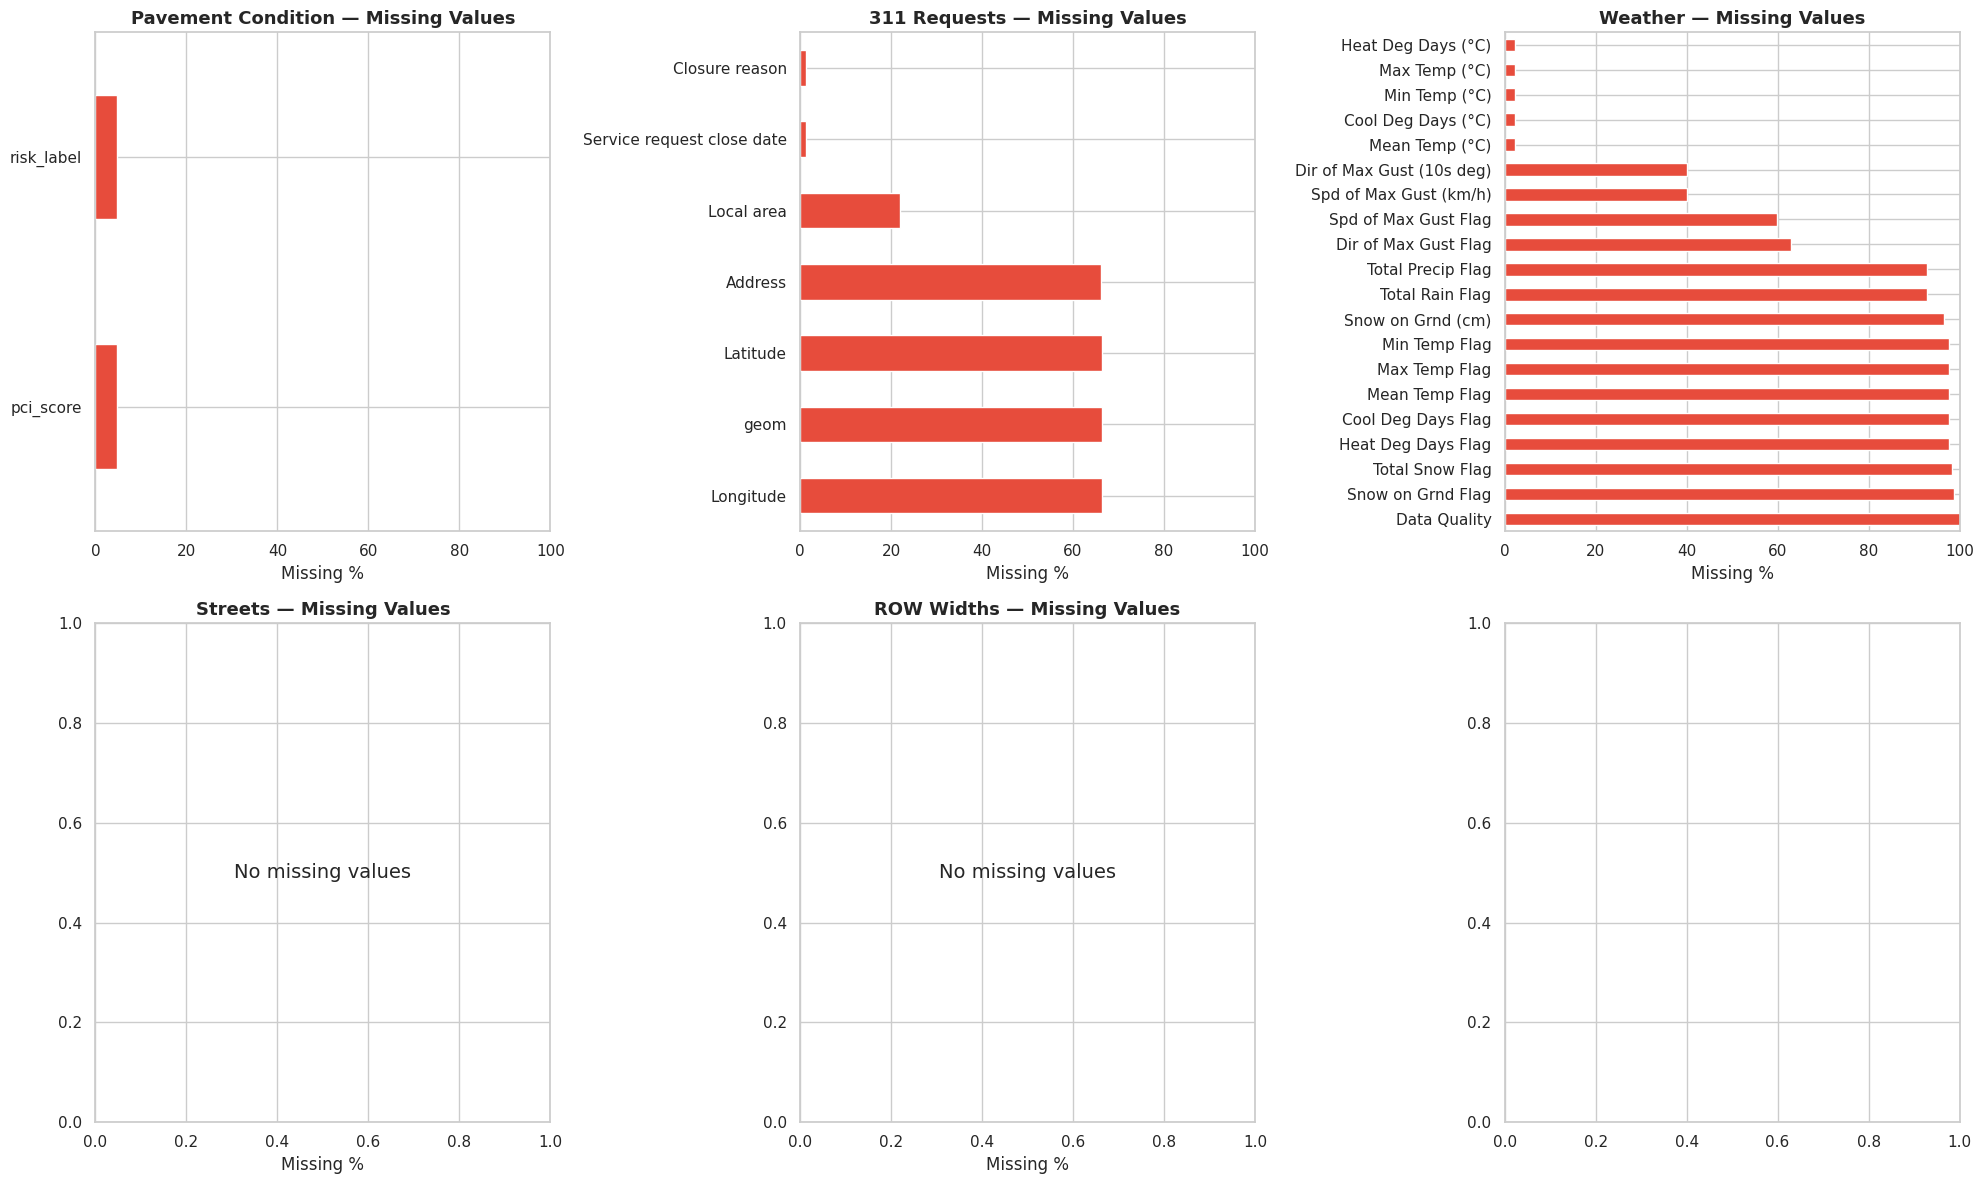

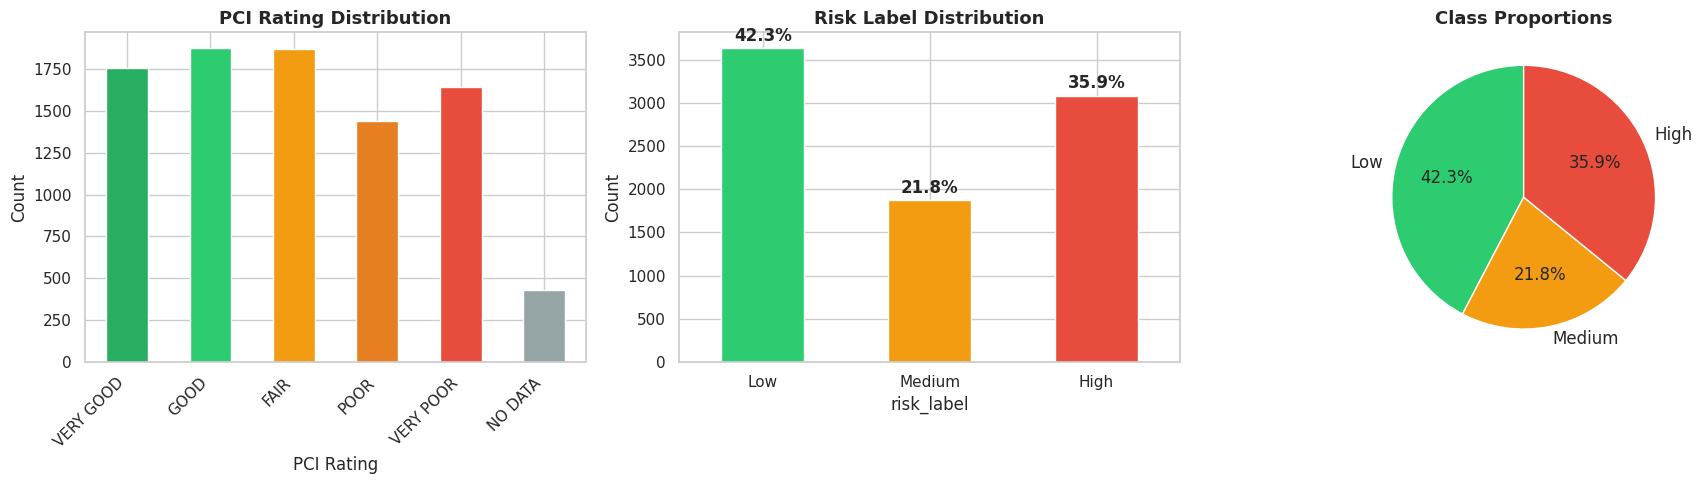

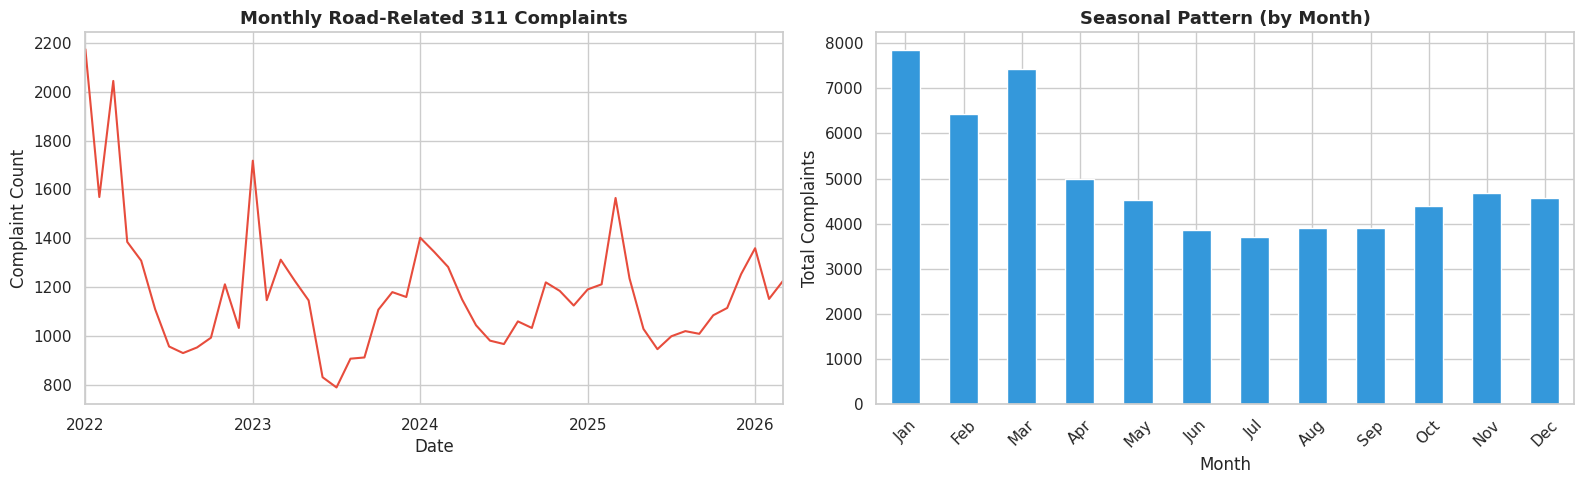

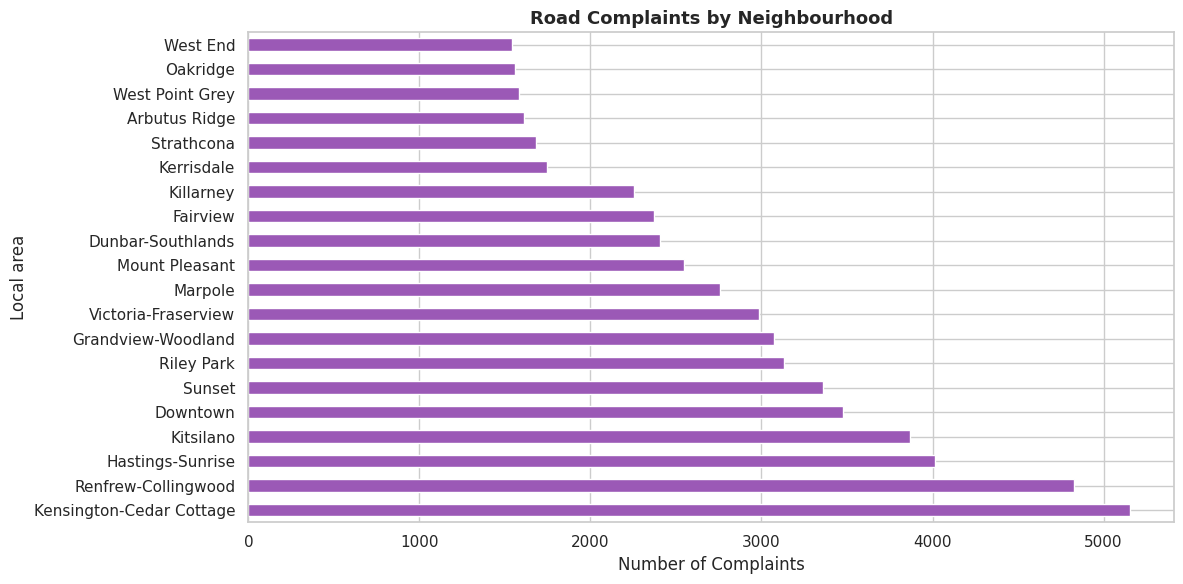

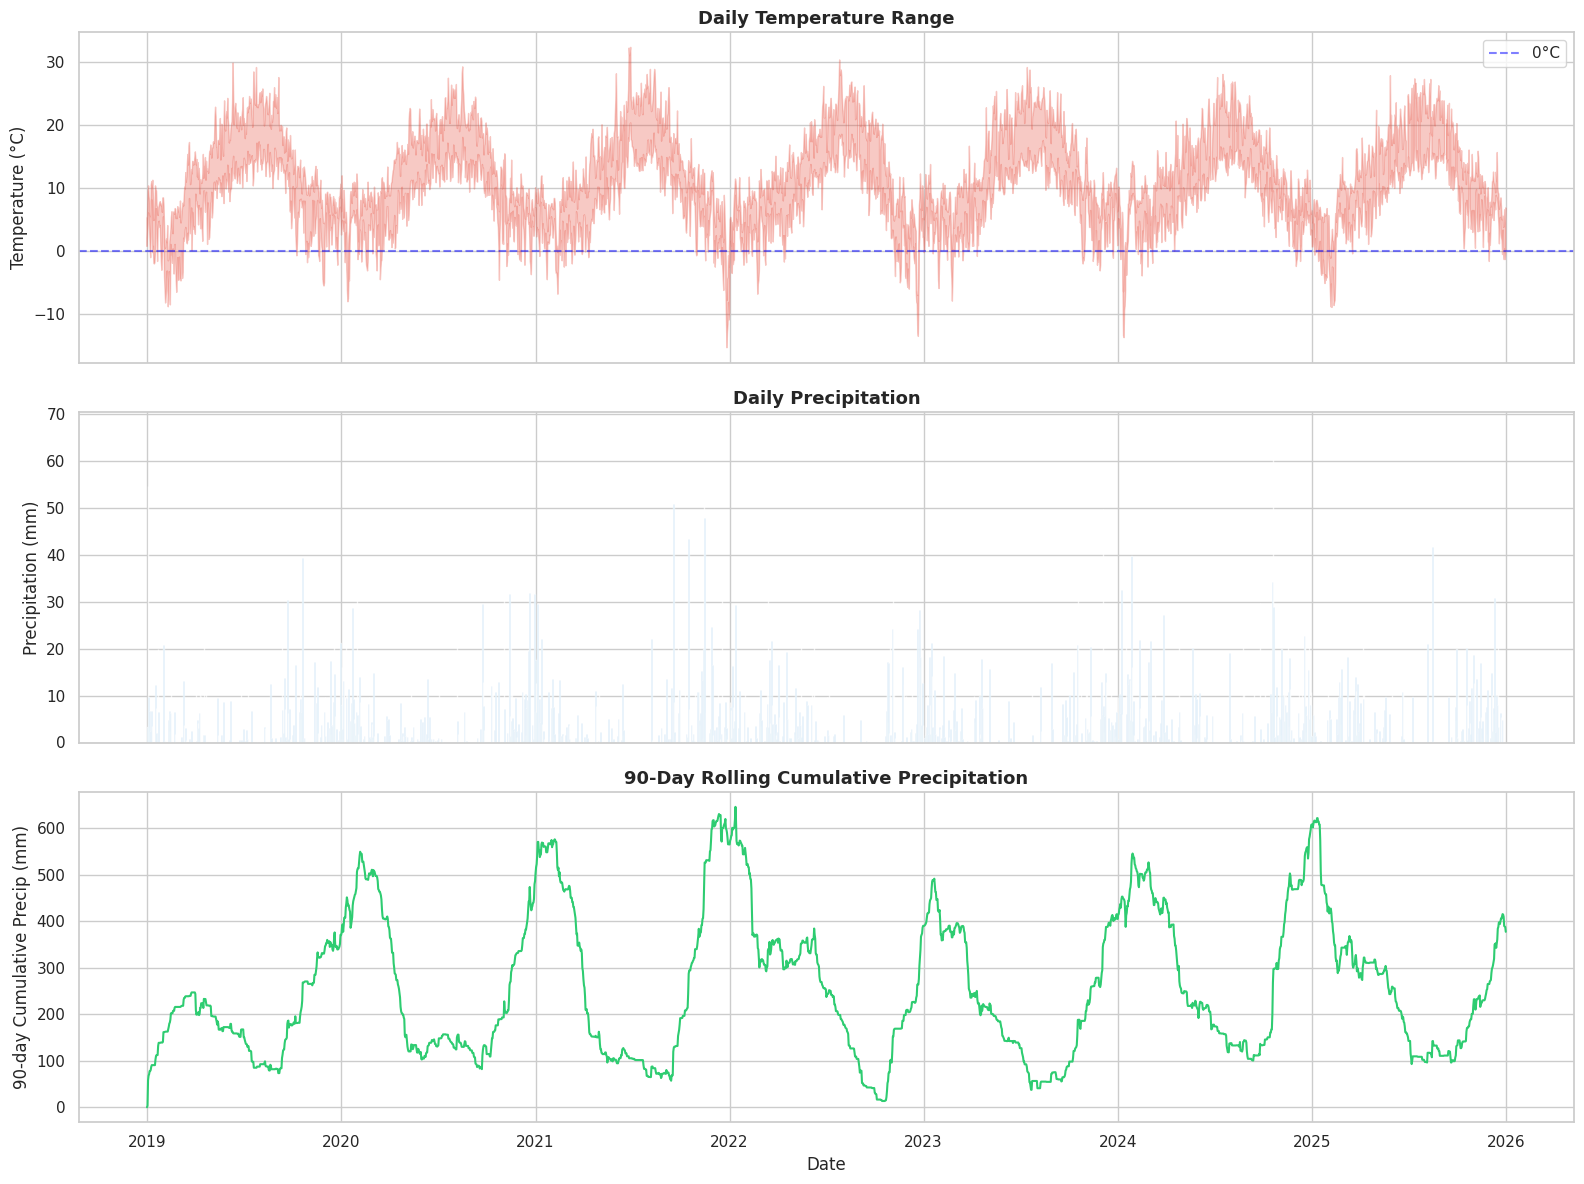

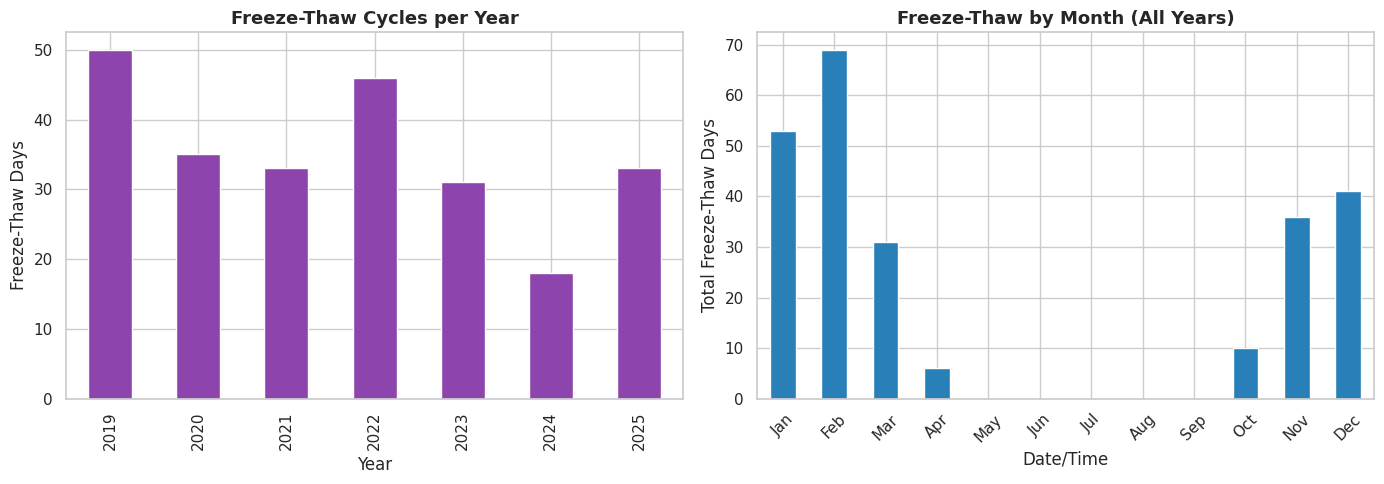

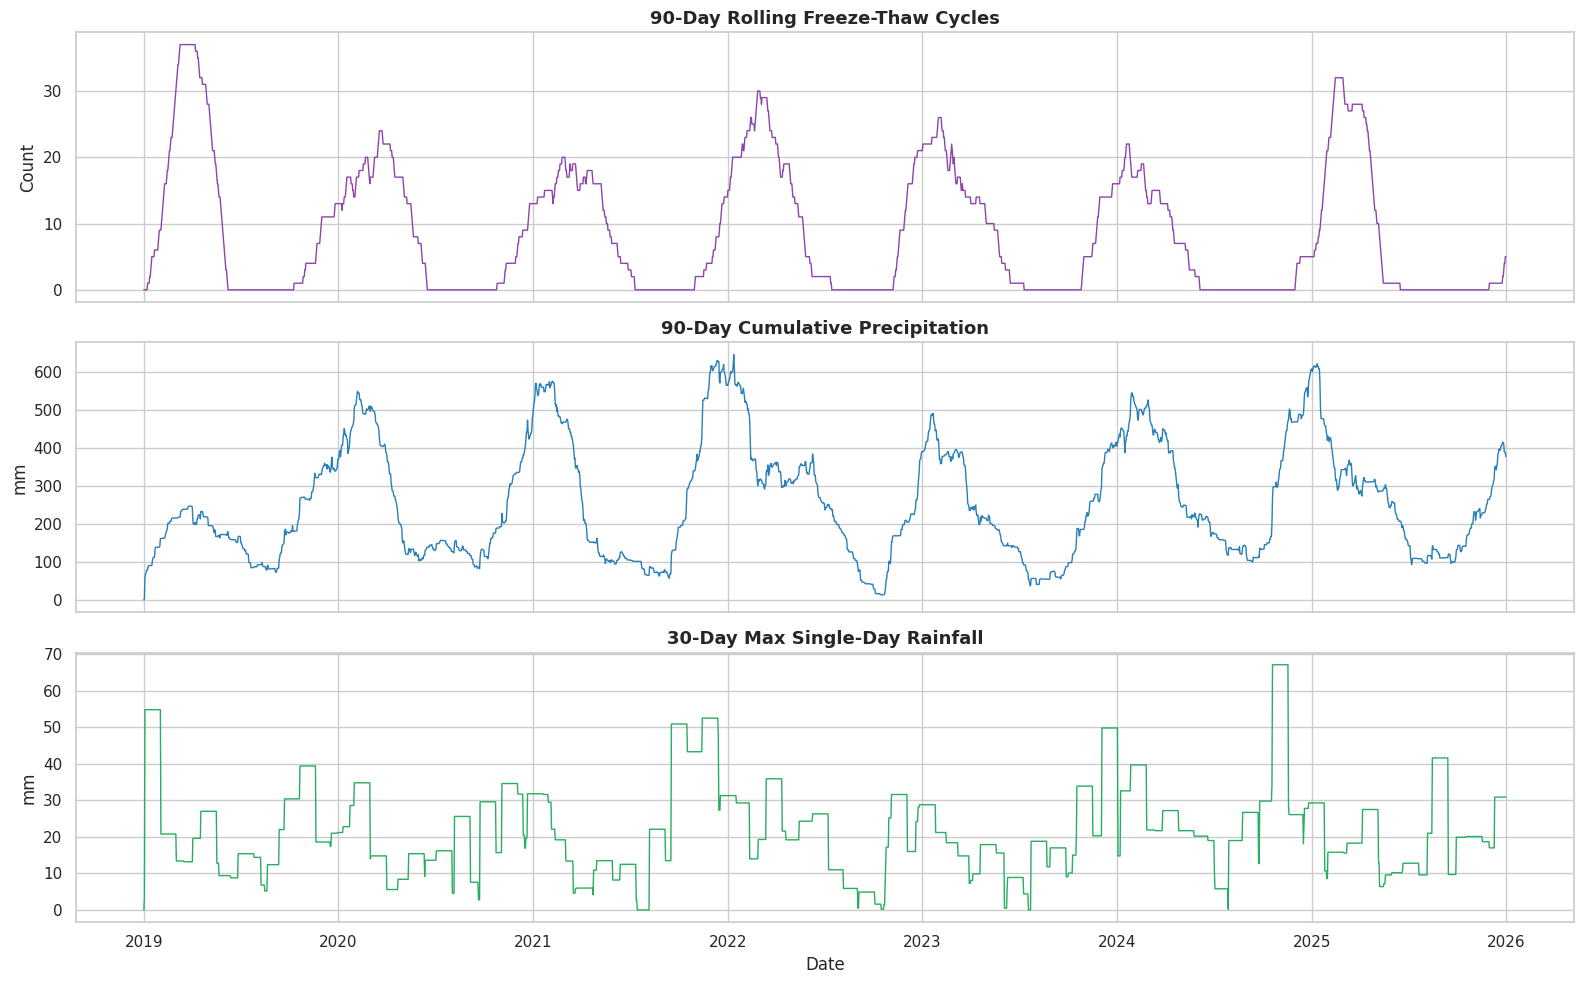

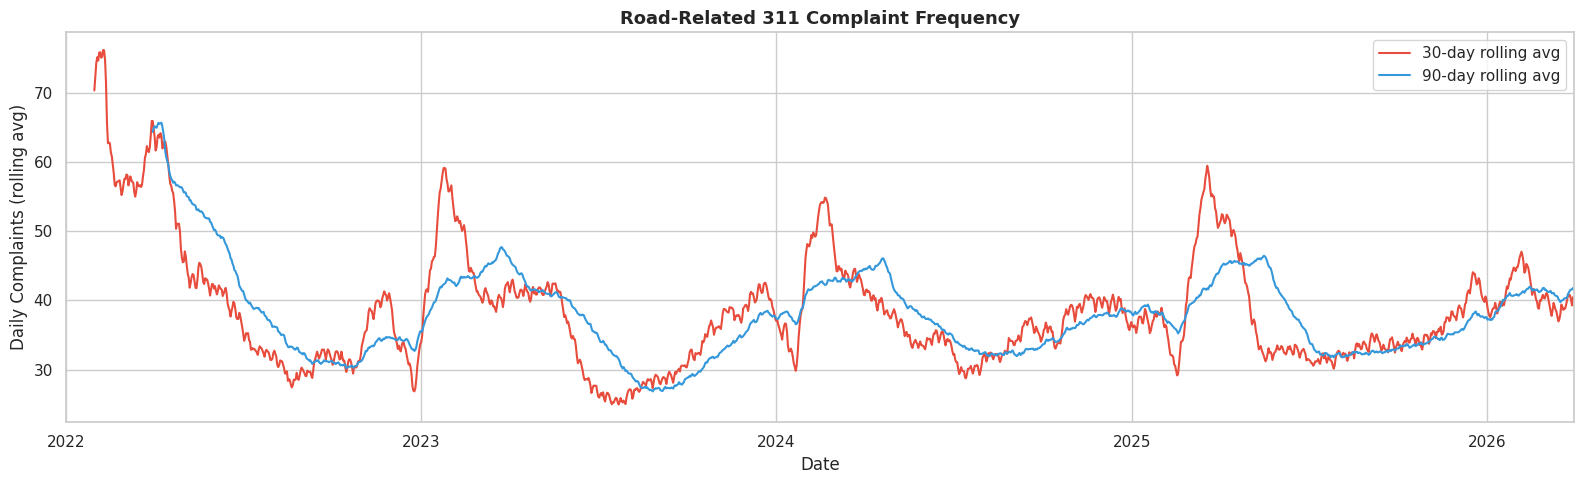

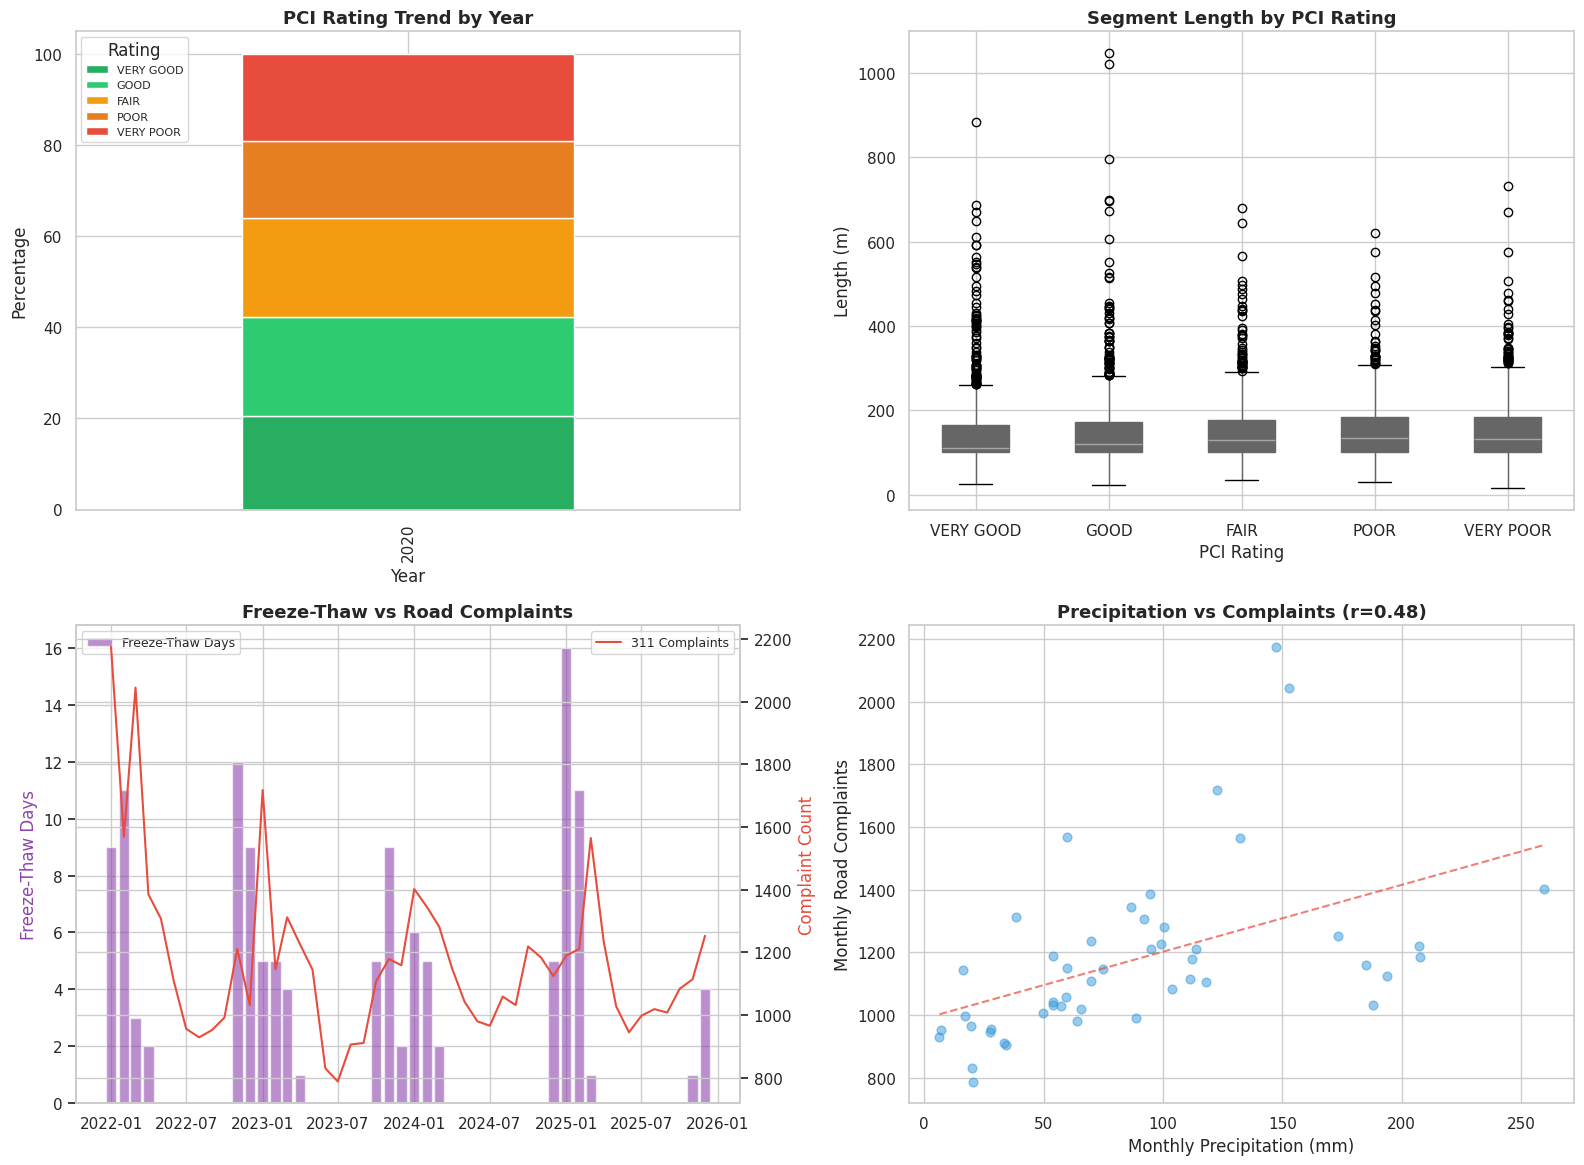


All figures saved to: /content/drive/MyDrive/CityBrain_EDA_Figures/
  01_missing_values.png
  02_risk_label_distribution.png
  03_311_temporal.png
  04_311_neighbourhood_bias.png
  05_weather_timeseries.png
  06_freeze_thaw.png
  07_weather_features.png
  08_311_frequency.png
  09_cross_dataset_analysis.png


In [37]:
# === Save all figures to Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/CityBrain_EDA_Figures/'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1) Missing Values ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
datasets_dict = {'Pavement Condition': df_pavement, '311 Requests': df_311, 'Weather': df_weather, 'Streets': df_streets, 'ROW Widths': df_row}
for ax, (name, df) in zip(axes.flat, datasets_dict.items()):
    missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0].head(20)
    if len(missing_pct) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    else:
        missing_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
        ax.set_xlim(0, 100)
    ax.set_xlabel('Missing %')
    ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2) Risk Label Distribution ---
if PCI_COL is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR', 'NO DATA']
    cat_counts = df_pavement[PCI_COL].str.upper().str.strip().value_counts().reindex(order).dropna()
    cat_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']
    cat_counts.plot(kind='bar', ax=axes[0], color=cat_colors[:len(cat_counts)], edgecolor='white')
    axes[0].set_title('PCI Rating Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    risk_counts = df_pavement['risk_label'].value_counts().reindex(['Low', 'Medium', 'High']).dropna()
    colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    risk_counts.plot(kind='bar', ax=axes[1], color=[colors.get(c, '#999') for c in risk_counts.index], edgecolor='white')
    axes[1].set_title('Risk Label Distribution', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    total = risk_counts.sum()
    for j, (label, count) in enumerate(risk_counts.items()):
        axes[1].text(j, count + total * 0.01, f'{count/total*100:.1f}%', ha='center', fontweight='bold')
    risk_pct = risk_counts / total * 100
    axes[2].pie(risk_pct, labels=risk_pct.index, autopct='%1.1f%%',
                colors=[colors.get(c, '#999') for c in risk_pct.index], startangle=90, textprops={'fontsize': 12})
    axes[2].set_title('Class Proportions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}02_risk_label_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 3) 311 Temporal ---
if DATE_COL_311:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    monthly = df_311_road.set_index(DATE_COL_311).resample('M').size()
    monthly.plot(ax=axes[0], color='#e74c3c', linewidth=1.5)
    axes[0].set_title('Monthly Road-Related 311 Complaints', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Complaint Count')
    seasonal = df_311_road.groupby(df_311_road[DATE_COL_311].dt.month).size()
    seasonal.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
    axes[1].set_title('Seasonal Pattern (by Month)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Total Complaints')
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}03_311_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 4) 311 Neighbourhood Bias ---
if area_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    area_counts = df_311_road[area_col].value_counts().head(20)
    area_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title('Road Complaints by Neighbourhood', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Complaints')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}04_311_neighbourhood_bias.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 5) Weather Time Series ---
if date_col_w and temp_min_col and precip_col:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    if temp_max_col:
        axes[0].fill_between(df_weather[date_col_w],
                             pd.to_numeric(df_weather[temp_min_col], errors='coerce'),
                             pd.to_numeric(df_weather[temp_max_col], errors='coerce'),
                             alpha=0.3, color='#e74c3c')
    axes[0].axhline(0, color='blue', linestyle='--', alpha=0.5, label='0°C')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title('Daily Temperature Range', fontsize=13, fontweight='bold')
    axes[0].legend()
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce')
    axes[1].bar(df_weather[date_col_w], precip_vals, width=1, color='#3498db', alpha=0.7)
    axes[1].set_ylabel('Precipitation (mm)')
    axes[1].set_title('Daily Precipitation', fontsize=13, fontweight='bold')
    rolling_precip = precip_vals.rolling(90, min_periods=1).sum()
    axes[2].plot(df_weather[date_col_w], rolling_precip, color='#2ecc71', linewidth=1.5)
    axes[2].set_ylabel('90-day Cumulative Precip (mm)')
    axes[2].set_title('90-Day Rolling Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}05_weather_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 6) Freeze-Thaw Analysis ---
if 'freeze_thaw' in df_weather.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ft_by_year = df_weather.groupby(df_weather[date_col_w].dt.year)['freeze_thaw'].sum()
    ft_by_year.plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='white')
    axes[0].set_title('Freeze-Thaw Cycles per Year', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Freeze-Thaw Days')
    axes[0].set_xlabel('Year')
    ft_by_month = df_weather.groupby(df_weather[date_col_w].dt.month)['freeze_thaw'].sum()
    ft_by_month.plot(kind='bar', ax=axes[1], color='#2980b9', edgecolor='white')
    axes[1].set_title('Freeze-Thaw by Month (All Years)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Total Freeze-Thaw Days')
    month_names2 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names2.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}06_freeze_thaw.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 7) Weather Features Preview ---
if date_col_w and precip_col and temp_min_col and temp_max_col:
    precip_v = pd.to_numeric(df_weather[precip_col], errors='coerce').fillna(0)
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    axes[0].plot(df_weather[date_col_w], df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum(), color='#8e44ad', linewidth=1)
    axes[0].set_ylabel('Count')
    axes[0].set_title('90-Day Rolling Freeze-Thaw Cycles', fontsize=13, fontweight='bold')
    axes[1].plot(df_weather[date_col_w], precip_v.rolling(90, min_periods=1).sum(), color='#2980b9', linewidth=1)
    axes[1].set_ylabel('mm')
    axes[1].set_title('90-Day Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].plot(df_weather[date_col_w], precip_v.rolling(30, min_periods=1).max(), color='#27ae60', linewidth=1)
    axes[2].set_ylabel('mm')
    axes[2].set_title('30-Day Max Single-Day Rainfall', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}07_weather_features.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 8) 311 Frequency Time Series ---
if DATE_COL_311:
    daily_complaints = df_311_road.set_index(DATE_COL_311).resample('D').size()
    fig, ax = plt.subplots(figsize=(16, 5))
    daily_complaints.rolling(30).mean().plot(ax=ax, label='30-day rolling avg', color='#e74c3c', linewidth=1.5)
    daily_complaints.rolling(90).mean().plot(ax=ax, label='90-day rolling avg', color='#3498db', linewidth=1.5)
    ax.set_title('Road-Related 311 Complaint Frequency', fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Complaints (rolling avg)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}08_311_frequency.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 9) Cross-Dataset Analysis ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
if PCI_COL and 'Year' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    ct = pd.crosstab(df_pav_clean['Year'], df_pav_clean[PCI_COL].str.upper().str.strip(), normalize='index') * 100
    ct = ct[[c for c in order if c in ct.columns]]
    ct.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
    axes[0, 0].set_title('PCI Rating Trend by Year', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage')
    axes[0, 0].legend(title='Rating', fontsize=8, loc='upper left')
if PCI_COL and 'length_(m)' in df_pavement.columns:
    df_pav_clean2 = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_pav_clean2['_pci'] = pd.Categorical(df_pav_clean2[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_pav_clean2.boxplot(column='length_(m)', by='_pci', ax=axes[0, 1], patch_artist=True)
    axes[0, 1].set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('PCI Rating')
    axes[0, 1].set_ylabel('Length (m)')
    plt.sca(axes[0, 1])
    plt.suptitle('')
if weather_monthly_ft is not None and complaints_monthly is not None:
    df_merge = pd.DataFrame({'freeze_thaw': weather_monthly_ft.values, 'month': weather_monthly_ft.index.to_period('M')}).merge(
        pd.DataFrame({'complaints': complaints_monthly.values, 'month': complaints_monthly.index.to_period('M')}), on='month', how='inner')
    if len(df_merge) > 0:
        months = df_merge['month'].dt.to_timestamp()
        axes[1, 0].bar(months, df_merge['freeze_thaw'], width=25, alpha=0.6, color='#8e44ad', label='Freeze-Thaw Days')
        ax3b = axes[1, 0].twinx()
        ax3b.plot(months, df_merge['complaints'], color='#e74c3c', linewidth=1.5, label='311 Complaints')
        axes[1, 0].set_title('Freeze-Thaw vs Road Complaints', fontsize=13, fontweight='bold')
        axes[1, 0].set_ylabel('Freeze-Thaw Days', color='#8e44ad')
        ax3b.set_ylabel('Complaint Count', color='#e74c3c')
        axes[1, 0].legend(loc='upper left', fontsize=9)
        ax3b.legend(loc='upper right', fontsize=9)
if precip_monthly is not None and complaints_monthly is not None:
    df_merge2 = pd.DataFrame({'precip': precip_monthly.values, 'month': precip_monthly.index.to_period('M')}).merge(
        pd.DataFrame({'complaints': complaints_monthly.values, 'month': complaints_monthly.index.to_period('M')}), on='month', how='inner')
    if len(df_merge2) > 0:
        axes[1, 1].scatter(df_merge2['precip'], df_merge2['complaints'], alpha=0.5, color='#3498db', s=40)
        x = df_merge2['precip'].values.astype(float)
        y = df_merge2['complaints'].values.astype(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 2:
            from numpy.polynomial.polynomial import polyfit
            b, m = polyfit(x[mask], y[mask], 1)
            xs = np.linspace(x[mask].min(), x[mask].max(), 100)
            axes[1, 1].plot(xs, b + m * xs, '--', color='#e74c3c', alpha=0.7)
            corr_val = np.corrcoef(x[mask], y[mask])[0, 1]
            axes[1, 1].set_title(f'Precipitation vs Complaints (r={corr_val:.2f})', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Monthly Precipitation (mm)')
        axes[1, 1].set_ylabel('Monthly Road Complaints')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}09_cross_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAll figures saved to: {SAVE_DIR}')
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith('.png'):
        print(f'  {f}')
